# Pipeline IFRS 9 – Probabilidad de Default (Freddie Mac)
**Maestría en Minería de Datos – UTN Facultad Regional Paraná**  
Autor: Sebastian Emiliano Meier | Director: Mag. Ing. Gustavo Denicolay

---

### Estructura del notebook

| Sección | Contenido |
|---|---|
| 0 | Configuración, imports y helpers |
| 1 | Ingesta de datos crudos (`data_reader.py`) |
| **1b** | **Paso 0 – Datos macroeconómicos FRED (FLI – IFRS 9 5.5.17c)** |
| 2 | Paso 1 – Panel longitudinal |
| 3 | Paso 2 – Definición de default IFRS 9 |
| **4** | **Análisis temporal: DPD, ODR y curvas de vintage** |
| **5** | **Chequeos de calidad del panel** |
| 6 | Paso 3 – Feature engineering (incluye variables macro FLI) |
| 7 | Paso 4 – Entrenamiento de modelos |
| **7b** | **Paso 3b – SICR basado en PD (IFRS 9 5.5.9 / EBA GL 135-138)** |
| 8 | Paso 5 – Calibración Lifetime PD |
| **8b** | **Paso 5b – Ponderación de escenarios macroeconómicos (IFRS 9 5.5.17c)** |
| 9 | Paso 6 – Validación regulatoria (+ backtesting transiciones + Lifetime PD) |
| 10 | Paso 7 – Explicabilidad SHAP |
| 11 | Ejecutar el pipeline completo |


## 0. Configuración

In [1]:
%matplotlib inline
import sys, os, warnings
from pathlib import Path

# ── Rutas ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent          # FreddieMAC/
SRC_DIR      = PROJECT_ROOT / "src"
DATA_DIR     = PROJECT_ROOT / "data"
FIG_DIR      = PROJECT_ROOT / "outputs" / "figuras"

sys.path.insert(0, str(PROJECT_ROOT))       # para data_reader
sys.path.insert(0, str(SRC_DIR))            # para config y pasos

warnings.filterwarnings("ignore")
os.chdir(SRC_DIR)                           # los scripts usan rutas relativas desde src/

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# ── Estilo gráfico ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "font.family": "serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("Blues_d", 8)

print("Configuración OK")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"SRC_DIR      : {SRC_DIR}")


Configuración OK
PROJECT_ROOT : C:\Users\sebat\Tesis Maestria\data\FreddieMAC
SRC_DIR      : C:\Users\sebat\Tesis Maestria\data\FreddieMAC\src


## 1. Ingesta de datos crudos (`data_reader.py`)
Lee los archivos `.txt` por vintage y genera `orig_all.parquet` y `svcg_all.parquet`.
**Omitir esta celda si los parquets ya existen.**


In [2]:
# ── Ejecutar solo si los parquets no existen ─────────────────────────────────
orig_p = DATA_DIR / "orig_all.parquet"
svcg_p = DATA_DIR / "svcg_all.parquet"

if not orig_p.exists() or not svcg_p.exists():
    os.chdir(PROJECT_ROOT)
    import importlib.util, sys as _sys
    spec = importlib.util.spec_from_file_location("data_reader", PROJECT_ROOT / "data_reader.py")
    dr = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(dr)
    dr.main()
    os.chdir(SRC_DIR)
    print("data_reader completado.")
else:
    print("Parquets ya existen – saltando ingesta.")


Parquets ya existen – saltando ingesta.


In [3]:
# ── Vista rápida de los parquets ─────────────────────────────────────────────
# orig_all/svcg_all son la salida CRUDA de data_reader.py: columnas con sufijo
# _V## (ej. credit_score_V1) y 'year' en vez de 'vintage_year'. La normalización
# de nombres vive en 01_carga_datos.py (normalizar_columnas) -> la reutilizamos
# aquí para no duplicar esa lógica.
import importlib.util as _iu
_spec01 = _iu.spec_from_file_location("m01_preview", SRC_DIR / "01_carga_datos.py")
_m01_preview = _iu.module_from_spec(_spec01); _spec01.loader.exec_module(_m01_preview)

orig = _m01_preview.normalizar_columnas(pd.read_parquet(DATA_DIR / "orig_all.parquet"))
svcg = _m01_preview.normalizar_columnas(pd.read_parquet(DATA_DIR / "svcg_all.parquet"))

print(f"orig_all : {orig.shape[0]:,} filas × {orig.shape[1]} cols")
print(f"svcg_all : {svcg.shape[0]:,} filas × {svcg.shape[1]} cols")
print(f"\nVintages en orig : {sorted(orig['vintage_year'].unique())}")
print(f"Vintages en svcg : {sorted(svcg['vintage_year'].unique())}")
print(f"\nPeríodo svcg : {svcg['monthly_reporting_period'].min()} → {svcg['monthly_reporting_period'].max()}")


orig_all : 400,000 filas × 33 cols
svcg_all : 14,603,212 filas × 33 cols

Vintages en orig : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2022), np.int32(2023), np.int32(2024)]
Vintages en svcg : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2022), np.int32(2023), np.int32(2024)]

Período svcg : 201602 → 202503


In [4]:
# ── Tipos y nulos en originación ─────────────────────────────────────────────
nulos_orig = (orig.isnull().mean() * 100).round(2).to_frame("% nulos")
nulos_orig["dtype"] = orig.dtypes.astype(str)
display(nulos_orig[nulos_orig["% nulos"] > 0].sort_values("% nulos", ascending=False))


,% nulos,dtype
relief_refinance_indicator,98.7800,str
pre_relief_refi_loan_seq_num,98.7800,str
super_conforming_flag,97.1200,str
msa_md_code,10.0500,float64


## 1b. Paso 0 – Datos Macroeconómicos FRED (FLI – IFRS 9 5.5.17c)

Descarga las 5 series macro de FRED requeridas para Forward-Looking Information:  
HPI (`USSTHPI`), desempleo (`UNRATE`), Fed Funds Rate (`FEDFUNDS`), GDP real (`GDPC1`), mortgage rate 30a (`MORTGAGE30US`).  

**Requisito:** variable de entorno `FRED_API_KEY`.  
Clave gratuita en: https://fred.stlouisfed.org/docs/api/api_key.html  
Windows: `set FRED_API_KEY=tu_clave_aqui`


In [5]:
import os

if os.environ.get('FRED_API_KEY'):
    import importlib.util as _iu
    spec = _iu.spec_from_file_location('m00', SRC_DIR / '00_macro_data.py')
    m = _iu.module_from_spec(spec)
    sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                                # clases definidas en este modulo (p.ej.
                                # ModeloCalibraado, _ModeloOrigCal); sin esto
                                # joblib.dump() falla con PicklingError.
    spec.loader.exec_module(m)
    macro_df = m.main()
else:
    print('FRED_API_KEY no configurada – paso 0 omitido.')
    print('Los features macro quedarán como NaN en el dataset de modelado.')
    macro_df = None


FRED_API_KEY no configurada – paso 0 omitido.
Los features macro quedarán como NaN en el dataset de modelado.


In [6]:
# ── Visualizar series macro si están disponibles ───────────────────────────────────────────────────────────
from pathlib import Path as _P
import pandas as _pd
macro_path = DATA_DIR / 'macro' / 'macro_monthly.parquet'
if macro_path.exists():
    macro_df = _pd.read_parquet(macro_path)
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    axes = axes.flatten()
    cols_plot = ['hpi', 'unemployment_rate', 'fed_funds_rate',
                 'gdp_real', 'mortgage_rate_30y', 'hpi_yoy_change']
    titulos   = ['House Price Index', 'Unemployment Rate (%)',
                 'Fed Funds Rate (%)', 'GDP Real (encadenado)',
                 'Mortgage Rate 30y (%)', 'HPI YoY Change (%)']
    for ax, col, tit in zip(axes, cols_plot, titulos):
        if col in macro_df.columns:
            ax.plot(macro_df['date'], macro_df[col], linewidth=1.5, color='#2166ac')
            ax.set_title(tit, fontweight='bold', fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.tick_params(labelsize=7)
    plt.suptitle('Series Macroeconómicas FRED – Forward-Looking Information',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'macro_fred_series.png', dpi=150)
    plt.show()
    display(macro_df.tail(6))
else:
    print('macro_monthly.parquet no encontrado – ejecutar celda anterior con FRED_API_KEY')


macro_monthly.parquet no encontrado – ejecutar celda anterior con FRED_API_KEY


## 2. Paso 1 – Panel longitudinal (`01_carga_datos.py`)
Une originación y performance en un panel `(préstamo × mes)`.


In [7]:
import importlib.util as _iu
panel_path = DATA_DIR / "panel.parquet"
if panel_path.exists():
    print("panel.parquet ya existe -- cargando solo columnas necesarias para el EDA (cache).")
    panel = pd.read_parquet(panel_path,
        columns=["loan_sequence_number", "monthly_reporting_period",
                 "vintage_year", "credit_score"])
else:
    spec = _iu.spec_from_file_location("m01", SRC_DIR / "01_carga_datos.py")
    m = _iu.module_from_spec(spec)
    sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                                # clases definidas en este modulo (p.ej.
                                # ModeloCalibraado, _ModeloOrigCal); sin esto
                                # joblib.dump() falla con PicklingError.
    spec.loader.exec_module(m)
    panel = m.main()


panel.parquet ya existe -- cargando solo columnas necesarias para el EDA (cache).


In [8]:
# ── Cobertura temporal por vintage ───────────────────────────────────────────
cob = (panel.groupby("vintage_year")["monthly_reporting_period"]
       .agg(inicio="min", fin="max", obs="count")
       .reset_index())
cob["obs"] = cob["obs"].map("{:,}".format)
display(cob)


,vintage_year,inicio,fin,obs
0,2016,2016-02-01,2025-03-01,"3,203,934"
1,2017,2017-02-01,2025-03-01,"2,644,947"
2,2018,2018-02-01,2025-03-01,"1,934,424"
3,2019,2019-02-01,2025-03-01,"1,756,455"
4,2020,2020-02-01,2025-03-01,"2,147,995"
5,2022,2022-01-01,2025-03-01,"1,533,564"
6,2023,2023-02-01,2025-03-01,"969,328"
7,2024,2024-02-01,2025-03-01,"412,565"


In [9]:
# ── Calidad del join: préstamos sin originación ───────────────────────────────
sin_orig = panel["credit_score"].isnull().sum()
total    = len(panel)
print(f"Filas sin datos de originación (credit_score NaN): {sin_orig:,} / {total:,}  ({sin_orig/total:.2%})")


Filas sin datos de originación (credit_score NaN): 2,621 / 14,603,212  (0.02%)


In [10]:
# ── Liberar memoria antes del Paso 2 ──────────────────────────────────────────
# 02_definicion_default.py vuelve a leer panel.parquet desde disco de forma
# independiente (para poder correrse también como script standalone), así que
# mantener orig/svcg/panel vivos en el notebook solo duplica RAM sin necesidad.
# El panel completo (64 columnas x ~14.6M filas) puede pesar varios GB en memoria.
import gc
del orig, svcg, panel
gc.collect()
print("Memoria liberada (orig, svcg, panel).")


Memoria liberada (orig, svcg, panel).


## 3. Paso 2 – Definición de default IFRS 9 (`02_definicion_default.py`)
Genera `dpd_numerico`, `evento_default`, `ifrs9_stage` y la variable objetivo `default_12m`.


In [11]:
import importlib.util as _iu
paneldef_path = DATA_DIR / "panel_con_default.parquet"
if paneldef_path.exists():
    print("panel_con_default.parquet ya existe -- cargando solo ifrs9_stage (cache).")
    panel_def = pd.read_parquet(paneldef_path, columns=["ifrs9_stage"])
else:
    spec = _iu.spec_from_file_location("m02", SRC_DIR / "02_definicion_default.py")
    m = _iu.module_from_spec(spec)
    sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                                # clases definidas en este modulo (p.ej.
                                # ModeloCalibraado, _ModeloOrigCal); sin esto
                                # joblib.dump() falla con PicklingError.
    spec.loader.exec_module(m)
    panel_def = m.main()


panel_con_default.parquet ya existe -- cargando solo ifrs9_stage (cache).


In [12]:
# ── Distribución de stages ────────────────────────────────────────────────────
stage_dist = (panel_def["ifrs9_stage"]
              .value_counts(normalize=True)
              .rename({1: "Stage 1", 2: "Stage 2", 3: "Stage 3"})
              .mul(100).round(2))
print("Distribución de stages (%):")
print(stage_dist.to_string())


Distribución de stages (%):
ifrs9_stage
Stage 1   98.1200
Stage 2    1.0500
Stage 3    0.8300


## 4. Análisis temporal: DPD, ODR y curvas de vintage

Estos chequeos usan el panel con default (`panel_con_default.parquet`) para diagnosticar
la calidad del portafolio a lo largo del tiempo.


### 4.1 Composición mensual del portafolio por bucket DPD

In [13]:
# ── Carga eficiente (solo columnas necesarias) ────────────────────────────────
cols = ["monthly_reporting_period", "dpd_numerico", "ifrs9_stage",
        "default_12m", "vintage_year", "loan_sequence_number"]
pdf = pd.read_parquet(DATA_DIR / "panel_con_default.parquet", columns=cols)

# Bucket DPD
def bucket_dpd(x):
    if pd.isna(x): return "Desconocido"
    if x == 0: return "0 – Al día"
    if x == 1: return "1 – 30 DPD"
    if x == 2: return "2 – 60 DPD"
    if x >= 3: return "3+ – Default"
    return "Desconocido"

pdf["bucket"] = pdf["dpd_numerico"].apply(bucket_dpd)
print(f"Panel cargado: {len(pdf):,} filas | {pdf['loan_sequence_number'].nunique():,} préstamos únicos")


Panel cargado: 14,603,212 filas | 400,000 préstamos únicos


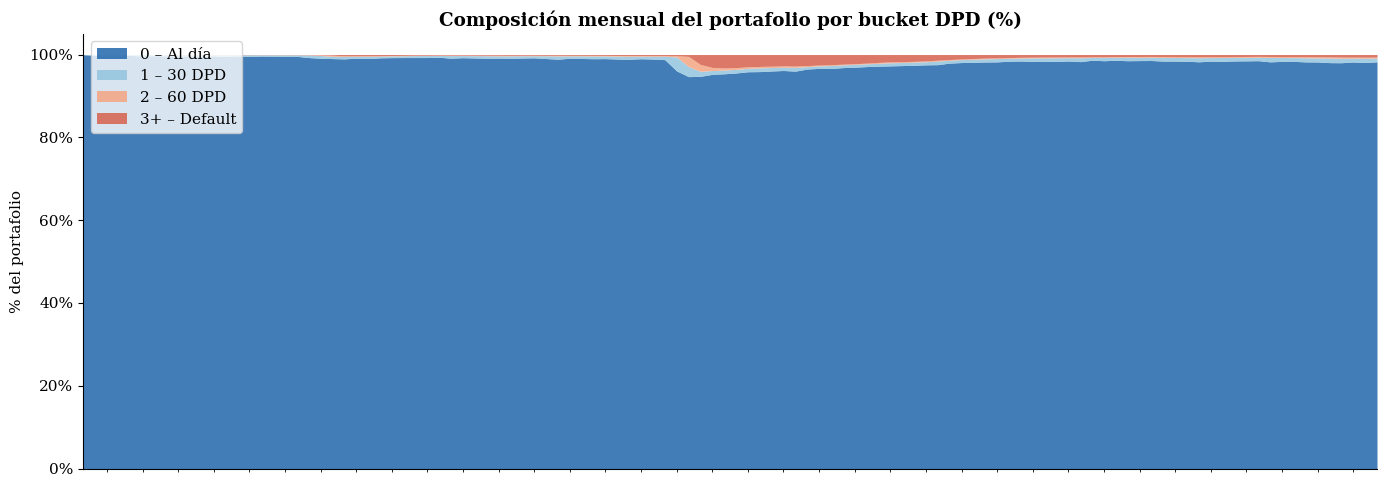

In [14]:
# ── % mensual por bucket ─────────────────────────────────────────────────────
dpd_mes = (pdf.groupby(["monthly_reporting_period", "bucket"])
           .size().unstack(fill_value=0))

# Normalizar a %
dpd_mes_pct = dpd_mes.div(dpd_mes.sum(axis=1), axis=0) * 100

orden = ["0 – Al día", "1 – 30 DPD", "2 – 60 DPD", "3+ – Default"]
dpd_mes_pct = dpd_mes_pct.reindex(columns=[c for c in orden if c in dpd_mes_pct.columns])

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#2166ac", "#92c5de", "#f4a582", "#d6604d"]
dpd_mes_pct.plot.area(ax=ax, color=colors, linewidth=0, alpha=0.85)
ax.set_title("Composición mensual del portafolio por bucket DPD (%)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("% del portafolio")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="upper left", framealpha=0.8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig(FIG_DIR / "dpd_composicion_mensual.png", dpi=150)
plt.show()


### 4.2 ODR – Observed Default Rate mensual

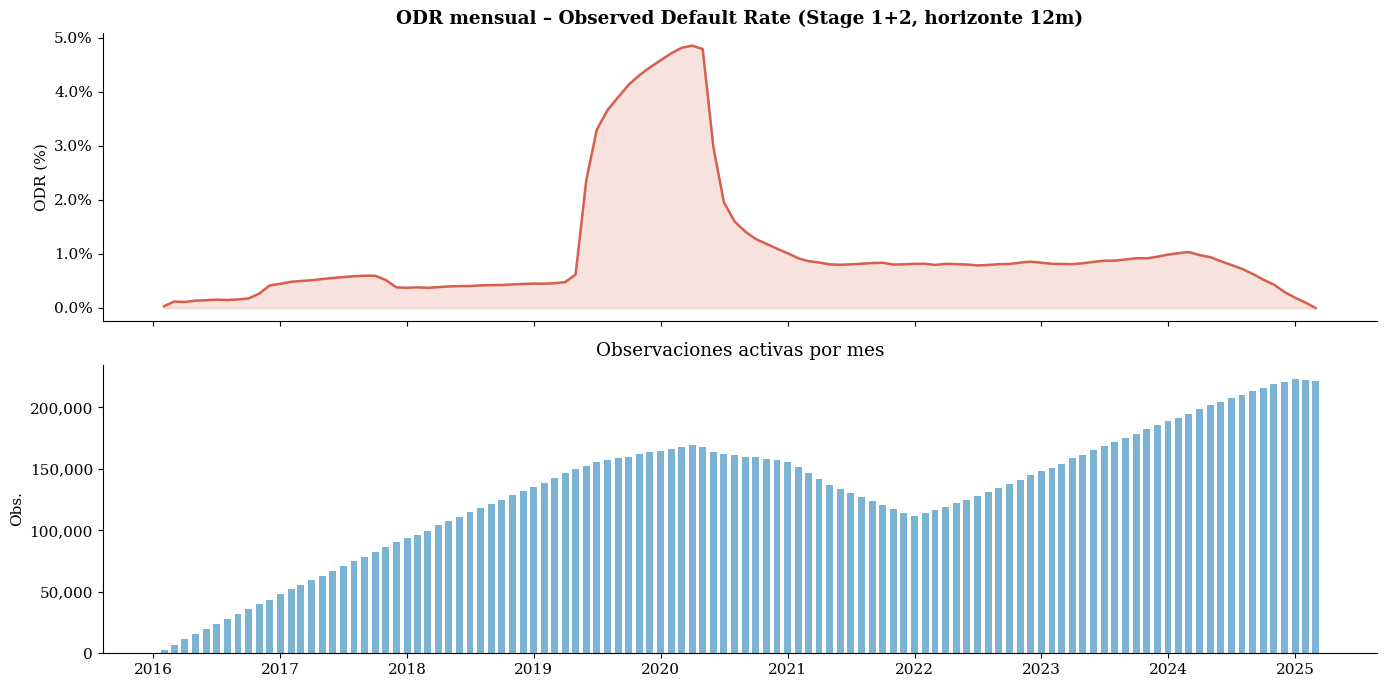

                           n_obs  n_default  ODR (%)
monthly_reporting_period                            
2023-04-01                158544       1285   0.8105
2023-05-01                161479       1337   0.8280
2023-06-01                165052       1409   0.8537
2023-07-01                168516       1474   0.8747
2023-08-01                171974       1507   0.8763
2023-09-01                175412       1574   0.8973
2023-10-01                178428       1643   0.9208
2023-11-01                182380       1677   0.9195
2023-12-01                185618       1761   0.9487
2024-01-01                188577       1863   0.9879
2024-02-01                191246       1943   1.0160
2024-03-01                194677       2016   1.0356
2024-04-01                198602       1944   0.9788
2024-05-01                201923       1903   0.9424
2024-06-01                204811       1774   0.8662
2024-07-01                207809       1656   0.7969
2024-08-01                210497       1527   

In [15]:
# ── ODR mensual: % de obs Stage 1/2 que tienen default_12m=1 ─────────────────
activos = pdf[pdf["ifrs9_stage"].isin([1, 2])].copy()

odr = (activos.groupby("monthly_reporting_period")
       .agg(
           n_obs     = ("default_12m", "count"),
           n_default = ("default_12m", "sum"),
       )
       .assign(odr_pct = lambda d: d["n_default"] / d["n_obs"] * 100)
       .reset_index())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ODR
axes[0].plot(odr["monthly_reporting_period"], odr["odr_pct"],
             color="#d6604d", linewidth=1.8)
axes[0].fill_between(odr["monthly_reporting_period"], odr["odr_pct"],
                     alpha=0.18, color="#d6604d")
axes[0].set_title("ODR mensual – Observed Default Rate (Stage 1+2, horizonte 12m)", fontweight="bold")
axes[0].set_ylabel("ODR (%)")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Volumen de observaciones
axes[1].bar(odr["monthly_reporting_period"], odr["n_obs"],
            width=20, color="#4393c3", alpha=0.7)
axes[1].set_title("Observaciones activas por mes")
axes[1].set_ylabel("Obs.")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(FIG_DIR / "odr_mensual.png", dpi=150)
plt.show()

print(odr[["monthly_reporting_period","n_obs","n_default","odr_pct"]]
      .rename(columns={"odr_pct":"ODR (%)"})
      .set_index("monthly_reporting_period").tail(24).to_string())


### 4.3 Curvas de vintage – tasa de default acumulada por cohorte

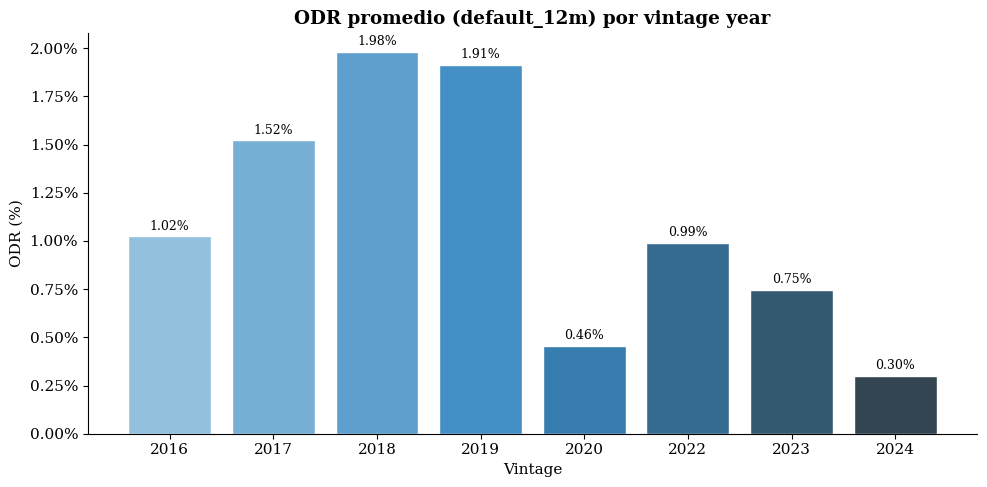

,vintage_year,odr_pct,n_obs
0,2016,1.024%,"3,182,109"
1,2017,1.521%,"2,615,737"
2,2018,1.982%,"1,907,583"
3,2019,1.911%,"1,732,417"
4,2020,0.456%,"2,140,030"
5,2022,0.989%,"1,525,412"
6,2023,0.748%,"966,118"
7,2024,0.301%,"412,065"


In [16]:
# ── Tasa de default_12m por vintage ──────────────────────────────────────────
# (Nota: `activos` ya está filtrado a Stage 1+2, por lo que dpd_numerico solo
# toma valores 0-2 aquí -- un bucket "3+" nunca puede tener observaciones y
# rompía este cálculo con KeyError; se elimina por no aportar información.)
odr_vintage = (activos
               .groupby("vintage_year")["default_12m"]
               .agg(odr_pct=lambda x: x.mean()*100, n_obs="count")
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(odr_vintage["vintage_year"].astype(str),
              odr_vintage["odr_pct"],
              color=sns.color_palette("Blues_d", len(odr_vintage)),
              edgecolor="white")
for bar, (_, row) in zip(bars, odr_vintage.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['odr_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("ODR promedio (default_12m) por vintage year", fontweight="bold")
ax.set_xlabel("Vintage")
ax.set_ylabel("ODR (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig(FIG_DIR / "odr_por_vintage.png", dpi=150)
plt.show()

display(odr_vintage.style.format({"odr_pct": "{:.3f}%", "n_obs": "{:,}"}))


### 4.4 Curvas de vintage – default acumulado por loan age

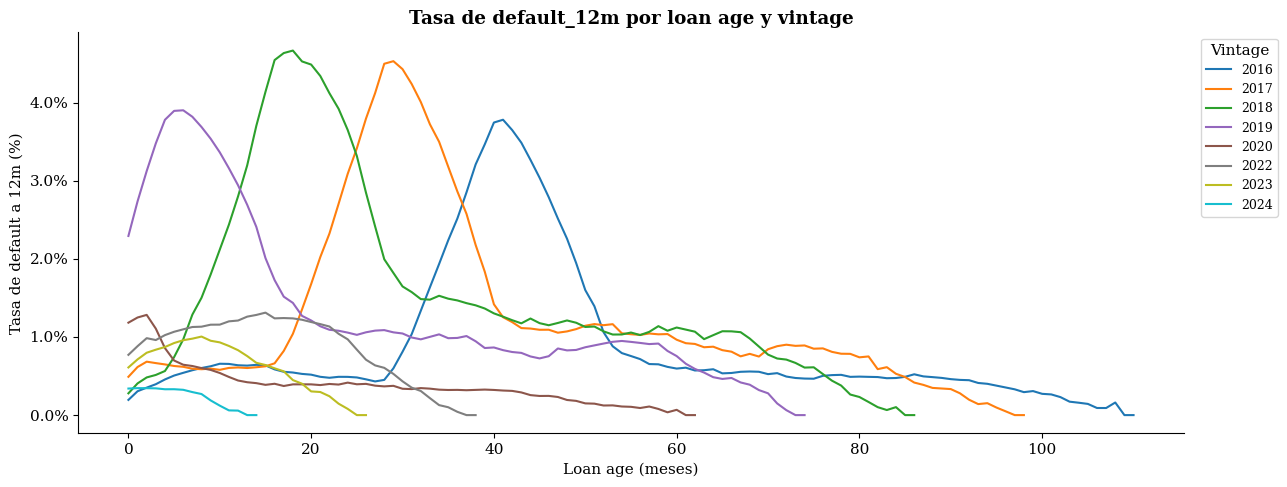

In [17]:
# ── Para cada vintage: % de préstamos únicos que defaultearon a cada loan_age ─
# Agrupamos por (vintage, loan_age) y calculamos la tasa de default promedio

# Necesitamos loan_age en el panel
cols2 = ["loan_sequence_number", "monthly_reporting_period",
         "vintage_year", "loan_age", "default_12m", "ifrs9_stage"]
try:
    pa2 = pd.read_parquet(DATA_DIR / "panel_con_default.parquet", columns=cols2)
except Exception:
    pa2 = pdf.copy()

activos2 = pa2[pa2["ifrs9_stage"].isin([1, 2])].copy()

vintage_age = (activos2
    .groupby(["vintage_year", "loan_age"])["default_12m"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"default_12m": "default_rate"}))

fig, ax = plt.subplots(figsize=(13, 5))
vintages = sorted(vintage_age["vintage_year"].unique())
cmap = plt.colormaps["tab10"].resampled(len(vintages))

for i, yr in enumerate(vintages):
    sub = vintage_age[vintage_age["vintage_year"] == yr].sort_values("loan_age")
    ax.plot(sub["loan_age"], sub["default_rate"],
            label=str(yr), color=cmap(i), linewidth=1.5)

ax.set_title("Tasa de default_12m por loan age y vintage", fontweight="bold")
ax.set_xlabel("Loan age (meses)")
ax.set_ylabel("Tasa de default a 12m (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Vintage", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "vintage_curves_loan_age.png", dpi=150)
plt.show()


### 4.5 Distribución mensual de DPD numérico (percentiles)

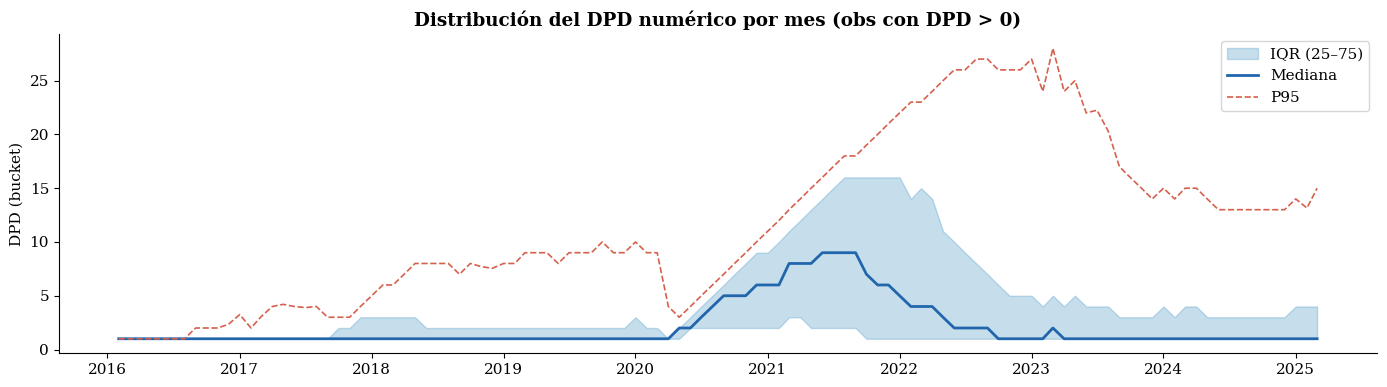

In [18]:
# ── Percentiles del DPD numérico por mes (solo obs con DPD > 0) ───────────────
dpd_pos = pdf[pdf["dpd_numerico"] > 0].copy()

dpd_stats = (dpd_pos
    .groupby("monthly_reporting_period")["dpd_numerico"]
    .agg(p25=lambda x: x.quantile(.25),
         mediana="median",
         p75=lambda x: x.quantile(.75),
         p95=lambda x: x.quantile(.95),
         n="count")
    .reset_index())

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(dpd_stats["monthly_reporting_period"],
                dpd_stats["p25"], dpd_stats["p75"],
                alpha=0.3, color="#4393c3", label="IQR (25–75)")
ax.plot(dpd_stats["monthly_reporting_period"], dpd_stats["mediana"],
        color="#2166ac", linewidth=2, label="Mediana")
ax.plot(dpd_stats["monthly_reporting_period"], dpd_stats["p95"],
        color="#d6604d", linewidth=1.2, linestyle="--", label="P95")
ax.set_title("Distribución del DPD numérico por mes (obs con DPD > 0)", fontweight="bold")
ax.set_ylabel("DPD (bucket)")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


### 4.6 Matriz de migración de stages (promedio anual)

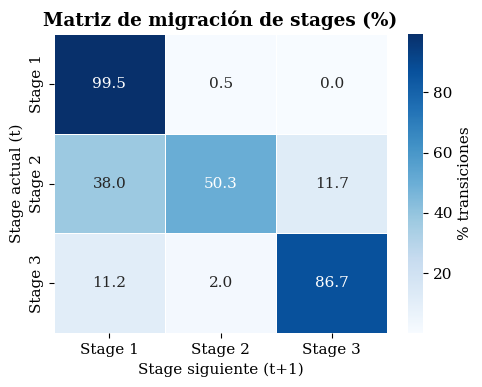

In [19]:
# ── Migración Stage t → Stage t+1 dentro de cada préstamo ────────────────────
stage_cols = ["loan_sequence_number", "monthly_reporting_period", "ifrs9_stage"]
sp = pdf[["loan_sequence_number","monthly_reporting_period","ifrs9_stage"]].copy()

sp = sp.sort_values(["loan_sequence_number","monthly_reporting_period"])
sp["next_stage"] = sp.groupby("loan_sequence_number")["ifrs9_stage"].shift(-1)
sp = sp.dropna(subset=["next_stage"])
sp["ifrs9_stage"]  = sp["ifrs9_stage"].astype(int)
sp["next_stage"]   = sp["next_stage"].astype(int)

trans = (sp.groupby(["ifrs9_stage","next_stage"])
         .size()
         .unstack(fill_value=0))
trans_pct = trans.div(trans.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(trans_pct, annot=True, fmt=".1f", cmap="Blues",
            linewidths=.5, ax=ax,
            xticklabels=["Stage 1","Stage 2","Stage 3"],
            yticklabels=["Stage 1","Stage 2","Stage 3"],
            cbar_kws={"label": "% transiciones"})
ax.set_title("Matriz de migración de stages (%)", fontweight="bold")
ax.set_xlabel("Stage siguiente (t+1)")
ax.set_ylabel("Stage actual (t)")
plt.tight_layout()
plt.savefig(FIG_DIR / "matriz_migracion_stages.png", dpi=150)
plt.show()


## 5. Chequeos de calidad del panel

Diagnósticos de integridad antes de proceder con feature engineering.


In [20]:
# ── Nulos por columna en el panel con default ─────────────────────────────────
nulos = (pdf.isnull().mean() * 100).round(2).to_frame("% nulos")
nulos["dtype"] = pdf.dtypes.astype(str)
nulos["n_nulos"] = pdf.isnull().sum()
print("Columnas con valores nulos:")
display(nulos[nulos["% nulos"] > 0].sort_values("% nulos", ascending=False))


Columnas con valores nulos:


,% nulos,dtype,n_nulos


In [21]:
# ── Duplicados (loan × mes) ───────────────────────────────────────────────────
dupes = pdf.duplicated(subset=["loan_sequence_number","monthly_reporting_period"]).sum()
print(f"Filas duplicadas (loan × mes): {dupes:,}")


Filas duplicadas (loan × mes): 0


In [22]:
# ── Distribución de loan_age ──────────────────────────────────────────────────
if "loan_age" in pdf.columns:
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(pdf["loan_age"].dropna(), bins=60, color="#4393c3", edgecolor="white")
    ax.set_title("Distribución del loan age (meses)", fontweight="bold")
    ax.set_xlabel("Loan age (meses)")
    ax.set_ylabel("Frecuencia")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x)}m"))
    plt.tight_layout()
    plt.show()


In [23]:
# ── Préstamos únicos por vintage ──────────────────────────────────────────────
unicos = (pdf.groupby("vintage_year")["loan_sequence_number"]
          .nunique()
          .reset_index()
          .rename(columns={"loan_sequence_number":"prestamos_unicos"}))
display(unicos.style.format({"prestamos_unicos": "{:,}"}))


,vintage_year,prestamos_unicos
0,2016,"50,000"
1,2017,"50,000"
2,2018,"50,000"
3,2019,"50,000"
4,2020,"50,000"
5,2022,"50,000"
6,2023,"50,000"
7,2024,"50,000"


## 6. Paso 3 – Feature engineering (`03_feature_engineering.py`)
Genera las variables predictoras y filtra las observaciones elegibles (Stage 1 y 2).


In [24]:
import importlib.util as _iu
dsmod_path = DATA_DIR / "dataset_modelado.parquet"
if dsmod_path.exists():
    print("dataset_modelado.parquet ya existe -- cargando desde cache.")
    dataset = pd.read_parquet(dsmod_path)
else:
    spec = _iu.spec_from_file_location("m03", SRC_DIR / "03_feature_engineering.py")
    m = _iu.module_from_spec(spec)
    sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                                # clases definidas en este modulo (p.ej.
                                # ModeloCalibraado, _ModeloOrigCal); sin esto
                                # joblib.dump() falla con PicklingError.
    spec.loader.exec_module(m)
    dataset = m.main()


dataset_modelado.parquet ya existe -- cargando desde cache.


In [25]:
from config import FEATURES_MODELO, TARGET, AÑOS_ENTRENAMIENTO, AÑOS_VALIDACION, AÑOS_TEST

# ── Resumen del dataset de modelado ──────────────────────────────────────────
print(f"Shape: {dataset.shape}")
print(f"\nTarget {TARGET}:")
print(dataset[TARGET].value_counts().to_string())
print(f"\nTasa de default global: {dataset[TARGET].mean():.4%}")


Shape: (14481471, 46)

Target default_12m:
default_12m
0    14304897
1      176574

Tasa de default global: 1.2193%


Features no disponibles en el dataset (omitidas, p.ej. macro sin FRED_API_KEY): ['hpi', 'unemployment_rate', 'fed_funds_rate', 'gdp_real', 'mortgage_rate_30y', 'hpi_yoy_change', 'unemployment_yoy_change']


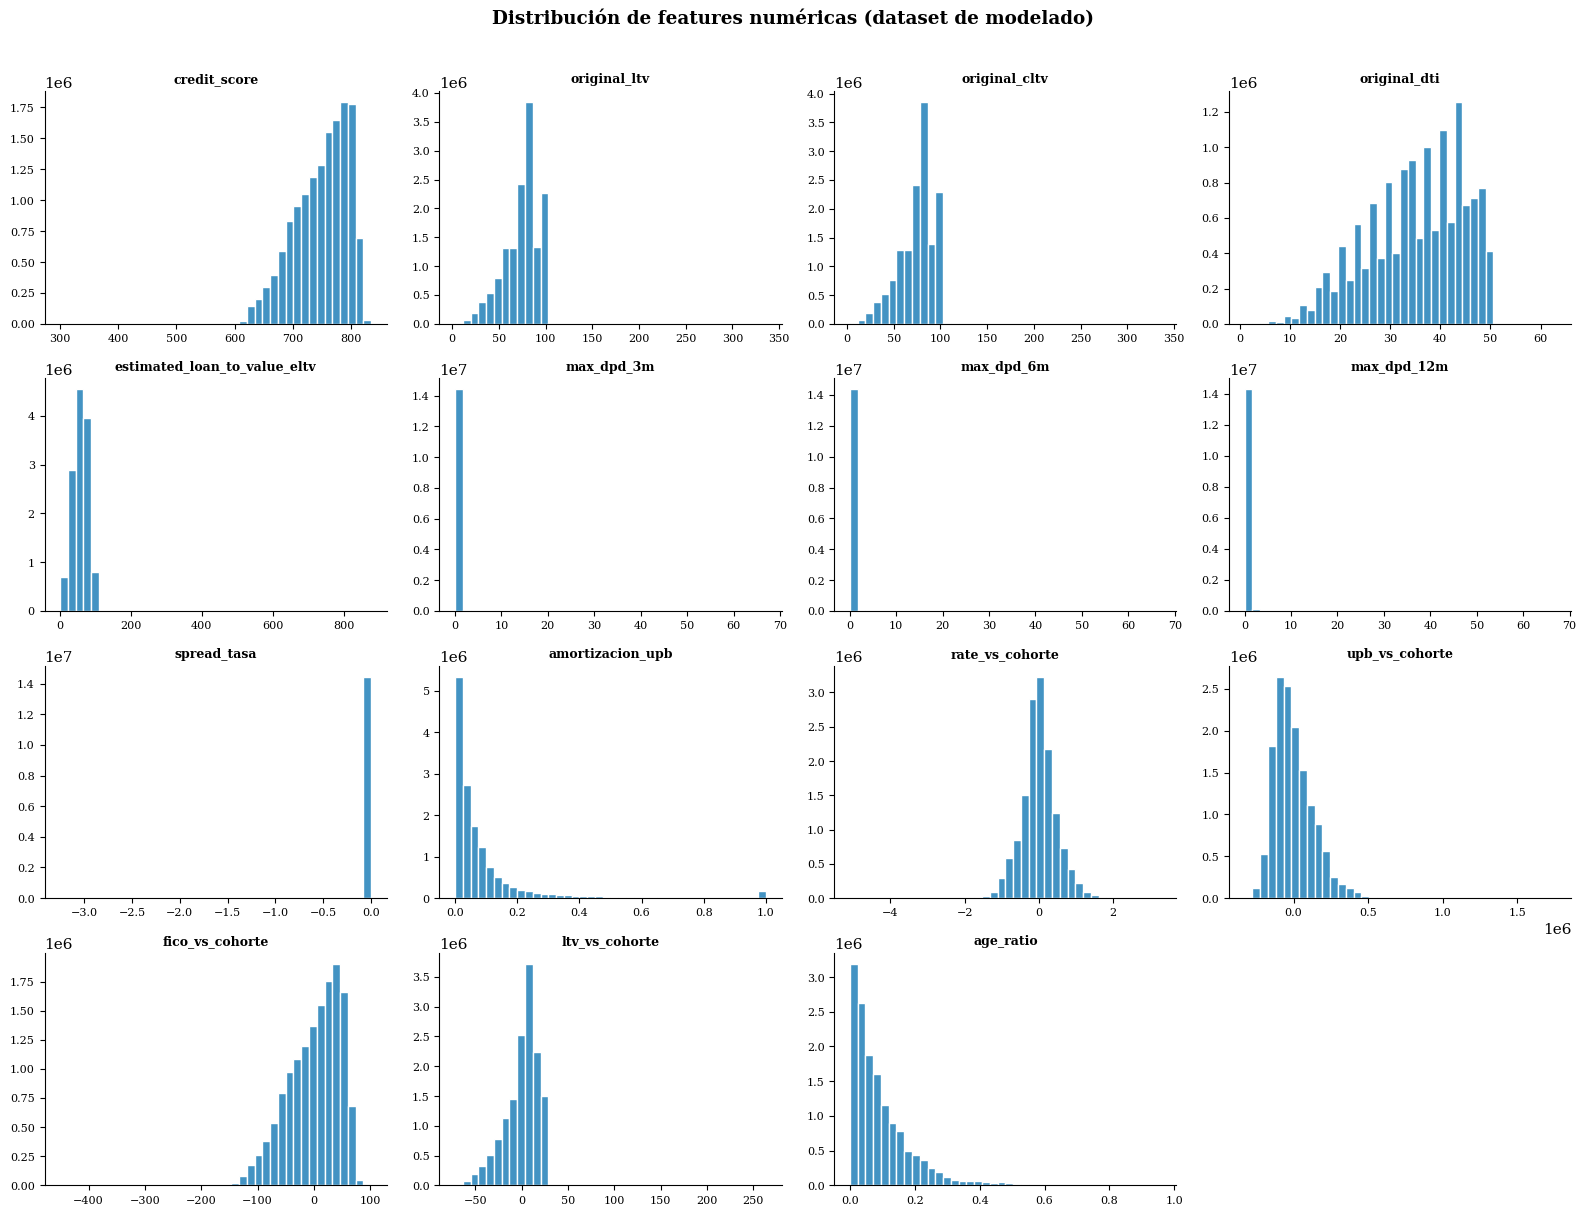

In [26]:
# ── Distribuciones de features numéricas ─────────────────────────────────────
feats_disp = [f for f in FEATURES_MODELO if f in dataset.columns]
faltantes = [f for f in FEATURES_MODELO if f not in dataset.columns]
if faltantes:
    print(f"Features no disponibles en el dataset (omitidas, p.ej. macro sin FRED_API_KEY): {faltantes}")

num_feats = [f for f in feats_disp if dataset[f].dtype in ["float32","float64"]]
n = len(num_feats)
cols_g = 4
rows_g = (n + cols_g - 1) // cols_g

fig, axes = plt.subplots(rows_g, cols_g, figsize=(16, rows_g * 3))
axes = axes.flatten()

for i, feat in enumerate(num_feats):
    axes[i].hist(dataset[feat].dropna(), bins=40, color="#4393c3", edgecolor="white")
    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].tick_params(labelsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de features numéricas (dataset de modelado)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [27]:
# ── % de nulos por feature ────────────────────────────────────────────────────
nulos_feat = (dataset[feats_disp]
              .isnull().mean().mul(100).round(2)
              .sort_values(ascending=False)
              .to_frame("% nulos"))
display(nulos_feat[nulos_feat["% nulos"] > 0])


,% nulos
estimated_loan_to_value_eltv,10.8700
original_dti,2.3100
fico_vs_cohorte,0.0200
credit_score,0.0200


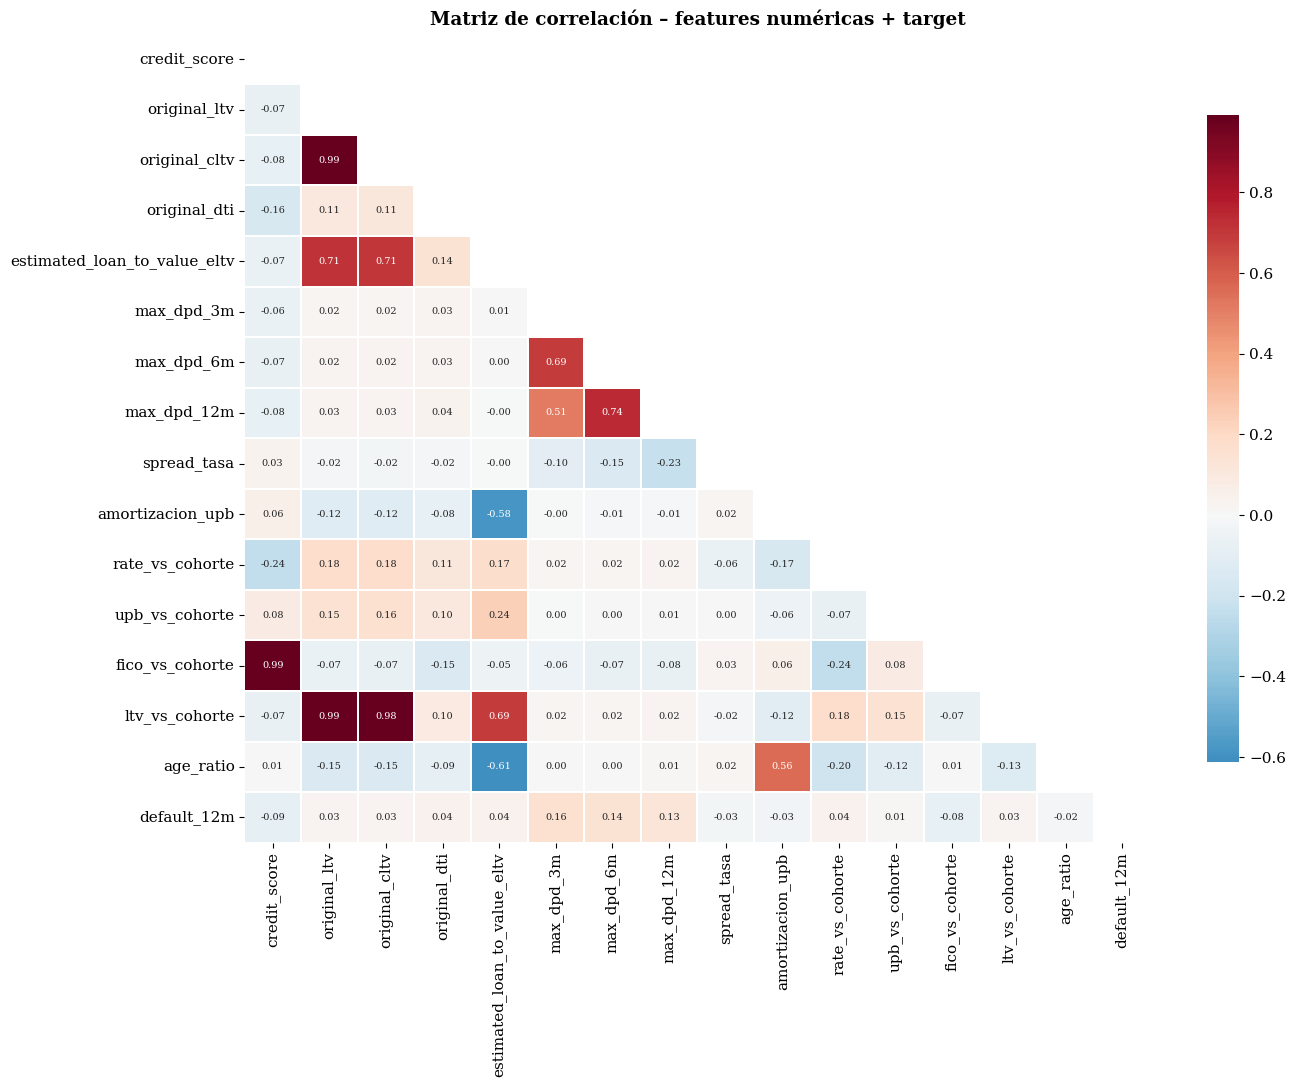

In [28]:
# ── Correlación entre features (solo numéricas) ───────────────────────────────
corr = dataset[num_feats + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=.3, ax=ax, annot_kws={"size": 7},
            cbar_kws={"shrink": .8})
ax.set_title("Matriz de correlación – features numéricas + target", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlacion_features.png", dpi=150)
plt.show()


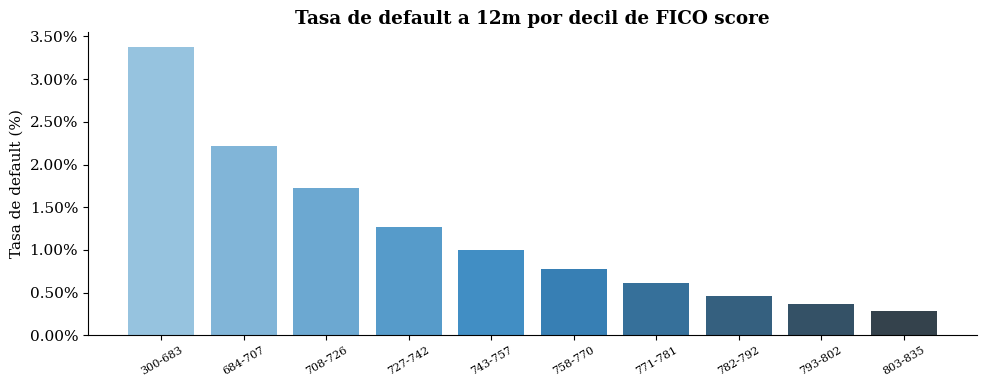

In [29]:
# ── Tasa de default por decil de credit_score ────────────────────────────────
ds_cs = dataset.dropna(subset=["credit_score"]).copy()
ds_cs["decil_cs"] = pd.qcut(ds_cs["credit_score"], q=10, labels=False, duplicates="drop")

cs_agg = (ds_cs.groupby("decil_cs")
          .agg(tasa_default=(TARGET,"mean"),
               n=("credit_score","count"),
               cs_min=("credit_score","min"),
               cs_max=("credit_score","max"))
          .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(cs_agg)), cs_agg["tasa_default"]*100,
              color=sns.color_palette("Blues_d", len(cs_agg)))
ax.set_xticks(range(len(cs_agg)))
ax.set_xticklabels([f"{int(r.cs_min)}-{int(r.cs_max)}" for _,r in cs_agg.iterrows()],
                   rotation=30, fontsize=8)
ax.set_title("Tasa de default a 12m por decil de FICO score", fontweight="bold")
ax.set_ylabel("Tasa de default (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()
del ds_cs


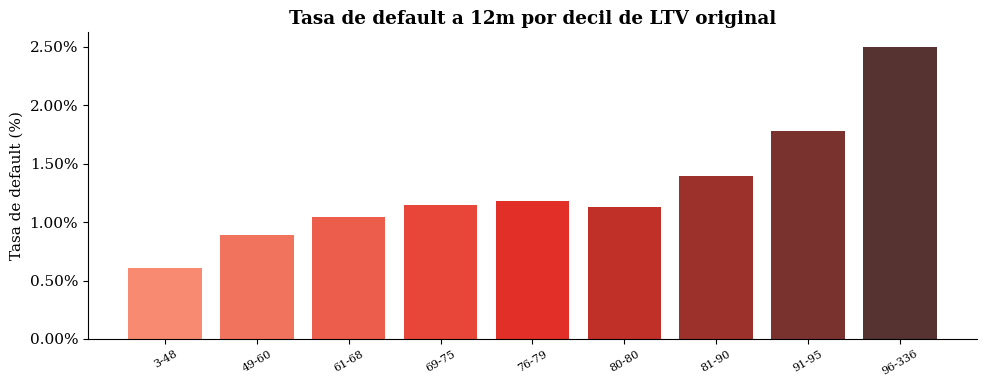

13831

In [30]:
# ── Tasa de default por decil de LTV ─────────────────────────────────────────
ds_ltv = dataset.dropna(subset=["original_ltv"]).copy()
ds_ltv["decil_ltv"] = pd.qcut(ds_ltv["original_ltv"], q=10, labels=False, duplicates="drop")

ltv_agg = (ds_ltv.groupby("decil_ltv")
           .agg(tasa_default=(TARGET,"mean"),
                n=("original_ltv","count"),
                ltv_min=("original_ltv","min"),
                ltv_max=("original_ltv","max"))
           .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(ltv_agg)), ltv_agg["tasa_default"]*100,
       color=sns.color_palette("Reds_d", len(ltv_agg)))
ax.set_xticks(range(len(ltv_agg)))
ax.set_xticklabels([f"{int(r.ltv_min)}-{int(r.ltv_max)}" for _,r in ltv_agg.iterrows()],
                   rotation=30, fontsize=8)
ax.set_title("Tasa de default a 12m por decil de LTV original", fontweight="bold")
ax.set_ylabel("Tasa de default (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()
del ds_ltv; gc.collect()


In [31]:
# -- Liberar memoria: `dataset` (14.5M filas) ya no se usa mas -----------------
# 04_modelado.py, 03b, 05, 06 y 07 leen su propia copia desde
# dataset_modelado.parquet de forma independiente. Mantenerlo vivo aca solo
# duplica RAM (entorno con ~16GB, criticamente ajustado durante el resto del
# pipeline) sin ningun beneficio para las celdas siguientes.
import gc
del dataset
gc.collect()
print("Memoria liberada (dataset).")


Memoria liberada (dataset).


## 7. Paso 4 – Entrenamiento de modelos (`04_modelado.py`)
Entrena Regresión Logística, XGBoost y Random Forest con calibración isotónica.
Partición out-of-time: train 2016–2020 | val 2022–2023 | test 2024.


In [32]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m04", SRC_DIR / "04_modelado.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
m.main()


PASO 4 – Entrenamiento de modelos PD


Dataset cargado: 14,481,471 filas

  ADVERTENCIA: features no disponibles (ignoradas): {'unemployment_rate', 'hpi_yoy_change', 'fed_funds_rate', 'gdp_real', 'mortgage_rate_30y', 'hpi', 'unemployment_yoy_change'}


  Entrenamiento : 11,577,876 obs | tasa default = 1.3217%
  Validación    :  2,491,530 obs | tasa default = 0.8952%
  Test          :    412,065 obs | tasa default = 0.3007%

  Ratio de desbalance (neg/pos): 74.7x


  Submuestreo entrenamiento: 1,000,000 obs (de 11,577,876)



  Early stopping (holdout interno vintage 2020): 100 árboles | AUC holdout = 0.8859

  [Logistica] Entrenando...


    Validación : AUC=0.8581 | Gini=0.7162 | Brier=0.0076
    Test       : AUC=0.8647 | Gini=0.7295 | Brier=0.0028
    Guardado: modelo_logistica.joblib

  [XGBoost] Entrenando...


    Validación : AUC=0.8639 | Gini=0.7278 | Brier=0.0075
    Test       : AUC=0.8540 | Gini=0.7080 | Brier=0.0028
    Guardado: modelo_xgboost.joblib

  [Random_Forest] Entrenando...


    Validación : AUC=0.8585 | Gini=0.7169 | Brier=0.0076
    Test       : AUC=0.8560 | Gini=0.7121 | Brier=0.0028
    Guardado: modelo_random_forest.joblib

  === RESUMEN COMPARATIVO ===
               AUC_val  Gini_val  Brier_val  AUC_test  Gini_test  Brier_test
Modelo                                                                      
Logistica       0.8581    0.7162     0.0076    0.8647     0.7295      0.0028
XGBoost         0.8639    0.7278     0.0075    0.8540     0.7080      0.0028
Random_Forest   0.8585    0.7169     0.0076    0.8560     0.7121      0.0028

Tabla guardada en: C:\Users\sebat\Tesis Maestria\data\FreddieMAC\outputs\tablas\resultados_modelos.csv
Paso 4 completado.



,AUC_val,Gini_val,Brier_val,AUC_test,Gini_test,Brier_test
Modelo,,,,,,
Logistica,0.8581,0.7162,0.0076,0.8647,0.7295,0.0028
XGBoost,0.8639,0.7278,0.0075,0.8540,0.7080,0.0028
Random_Forest,0.8585,0.7169,0.0076,0.8560,0.7121,0.0028


In [33]:
# ── Resultados de modelos ─────────────────────────────────────────────────────
from config import TABLAS_PATH
res = pd.read_csv(TABLAS_PATH / "resultados_modelos.csv")
cols_num = res.select_dtypes("number").columns
display(res.style.highlight_max(subset=cols_num, color="#d4efdf")
        .format("{:.4f}", subset=cols_num, na_rep="–"))


,Modelo,AUC_val,Gini_val,Brier_val,AUC_test,Gini_test,Brier_test
0,Logistica,0.8581,0.7162,0.0076,0.8647,0.7295,0.0028
1,XGBoost,0.8639,0.7278,0.0075,0.8540,0.7080,0.0028
2,Random_Forest,0.8585,0.7169,0.0076,0.8560,0.7121,0.0028


## 7b. Paso 3b – SICR basado en PD (IFRS 9 5.5.9)

Evalúa el Significant Increase in Credit Risk (SICR) comparando la PD corriente (del modelo XGBoost) con la PD estimada en originación (Regresión Logística).  

**Marco regulatorio:** IFRS 9 5.5.9 (criterio primario = variación de Lifetime PD)  
EBA GL 135-138: el backstop 30 DPD no debe ser el indicador principal de SICR.  

Criterio implementado:  
```
sicr_flag = (pd_current / pd_origination > 2.5) OR
            (pd_current - pd_origination > 0.005) OR
            (dpd_numerico >= 1)  # backstop
```

> **Dependencia:** debe ejecutarse después del Paso 4 (requiere modelo XGBoost entrenado).


In [34]:
import importlib.util as _iu
spec = _iu.spec_from_file_location('m03b', SRC_DIR / '03b_sicr_assessment.py')
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
m.main()  # no se captura: mantener el DF completo (14.5M filas) vivo
          # aqui duplicaria RAM sin uso -- la celda siguiente relee solo
          # las columnas que necesita directamente desde el parquet


PASO 3b – SICR basado en Lifetime PD (IFRS 9 5.5.9)


Dataset cargado: 14,481,471 filas

  Entrenando modelo de PD en originación (Logistic Regression)...


  Features de originación usadas: 15


  Cargando modelo XGBoost para PD corriente...



  Comparación de clasificación de stages:
  [DPD-based]
    Stage 1: 14,328,713 (98.9%)
    Stage 2:    152,758 (1.1%)
  [PD-based SICR]
    Stage 1: 13,256,089 (91.5%)
    Stage 2:  1,225,382 (8.5%)



  Stage 1(DPD) -> Stage 2(PD-SICR): 1,072,624 obs
  Stage 2(DPD) -> Stage 1(PD-SICR): 0 obs

  Disparadores del SICR (umbral k=2.5, delta=0.05):
    Criterio relativo  :    577,354
    Criterio absoluto  :  1,063,281
    Backstop 30 DPD    :    152,758
    Solo por backstop  :      1,169 (0.1% del Stage 2)

  PD media en originación : 0.6976%
  PD media corriente      : 0.7011%
  Lifetime PD originación : 14.3317%


  Lifetime PD corriente   : 9.8060%

  Calibración del umbral relativo k:


 k_relativo  delta_absoluto  pct_cartera_stage2  tasa_default_stage2  tasa_default_stage1  cobertura_defaults  pct_solo_por_backstop  rel_share  lift_stage2_vs_stage1
     1.5000          0.0100              0.1648               0.0355               0.0076              0.4806                 0.0000     0.0481                 4.6900
     2.0000          0.0100              0.1576               0.0371               0.0075              0.4794                 0.0000     0.0041                 4.9200
     2.5000          0.0100              0.1575               0.0371               0.0075              0.4794                 0.0000     0.0035                 4.9300
     3.0000          0.0100              0.1569               0.0372               0.0075              0.4794                 0.0000     0.0001                 4.9500
     4.0000          0.0100              0.1569               0.0372               0.0075              0.4794                 0.0000     0.0000                 4.950


Dataset actualizado guardado en: C:\Users\sebat\Tesis Maestria\data\FreddieMAC\data\dataset_modelado.parquet
Paso 3b completado.



,original_ltv,loan_purpose,monthly_reporting_period,original_dti,current_actual_upb,amortization_type,default_12m,dpd_numerico,original_interest_rate,vintage_year,number_of_borrowers,current_interest_rate,loan_sequence_number,channel,payment_deferral_flag,loan_age,ifrs9_stage,property_type,original_cltv,occupancy_status,number_of_units,credit_score,modification_flag,estimated_loan_to_value_eltv,original_upb,original_loan_term,max_dpd_3m,max_dpd_6m,max_dpd_12m,spread_tasa,amortizacion_upb,rate_vs_cohorte,upb_vs_cohorte,fico_vs_cohorte,ltv_vs_cohorte,age_ratio,fue_modificado,tiene_deferral,pd_origination,pd_current,plazo_residual_meses,pd_lifetime_current,pd_lifetime_orig,sicr_ratio,sicr_pd_flag,ifrs9_stage_sicr
0,65.0000,0,2016-03-01,41.0000,"125,000.0000",0,0,0,3.7500,2016,2,3.7500,F16Q10000006,2,NaN,0,1,2,65.0000,1,1,686.0000,NaN,NaN,125000,240,0.0000,0.0000,0.0000,0.0000,0.0000,-0.2554,"-79,831.2188",-59.8134,-7.2713,0.0000,0,0,0.0040,0.0035,240,0.0685,0.0779,0.8793,0,1
1,65.0000,0,2016-04-01,41.0000,"124,000.0000",0,0,0,3.7500,2016,2,3.7500,F16Q10000006,2,NaN,1,1,2,65.0000,1,1,686.0000,NaN,NaN,125000,240,0.0000,0.0000,0.0000,0.0000,0.0080,-0.2554,"-79,831.2188",-59.8134,-7.2713,0.0042,0,0,0.0040,0.0035,239,0.0682,0.0776,0.8793,0,1
2,65.0000,0,2016-05-01,41.0000,"124,000.0000",0,0,0,3.7500,2016,2,3.7500,F16Q10000006,2,NaN,2,1,2,65.0000,1,1,686.0000,NaN,NaN,125000,240,0.0000,0.0000,0.0000,0.0000,0.0080,-0.2554,"-79,831.2188",-59.8134,-7.2713,0.0083,0,0,0.0040,0.0035,238,0.0679,0.0772,0.8793,0,1
3,65.0000,0,2016-06-01,41.0000,"124,000.0000",0,0,0,3.7500,2016,2,3.7500,F16Q10000006,2,NaN,3,1,2,65.0000,1,1,686.0000,NaN,NaN,125000,240,0.0000,0.0000,0.0000,0.0000,0.0080,-0.2554,"-79,831.2188",-59.8134,-7.2713,0.0125,0,0,0.0040,0.0035,237,0.0676,0.0769,0.8793,0,1
4,65.0000,0,2016-07-01,41.0000,"123,000.0000",0,0,0,3.7500,2016,2,3.7500,F16Q10000006,2,NaN,4,1,2,65.0000,1,1,686.0000,NaN,NaN,125000,240,0.0000,0.0000,0.0000,0.0000,0.0160,-0.2554,"-79,831.2188",-59.8134,-7.2713,0.0167,0,0,0.0040,0.0035,236,0.0674,0.0766,0.8792,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14481466,80.0000,2,2024-11-01,43.0000,"244,000.0000",0,0,0,6.9900,2024,2,6.9900,F24Q40281890,2,NaN,0,1,4,80.0000,1,1,641.0000,NaN,80.0000,244000,360,0.0000,0.0000,0.0000,0.0000,0.0000,0.8386,"-104,537.2422",-114.2612,6.1840,0.0000,0,0,0.0163,0.0183,360,0.4262,0.3888,1.0963,0,1
14481467,80.0000,2,2024-12-01,43.0000,"244,000.0000",0,0,0,6.9900,2024,2,6.9900,F24Q40281890,2,NaN,1,1,4,80.0000,1,1,641.0000,NaN,79.0000,244000,360,0.0000,0.0000,0.0000,0.0000,0.0000,0.8386,"-104,537.2422",-114.2612,6.1840,0.0028,0,0,0.0163,0.0183,359,0.4253,0.3880,1.0964,0,1
14481468,80.0000,2,2025-01-01,43.0000,"244,000.0000",0,0,0,6.9900,2024,2,6.9900,F24Q40281890,2,NaN,2,1,4,80.0000,1,1,641.0000,NaN,79.0000,244000,360,0.0000,0.0000,0.0000,0.0000,0.0000,0.8386,"-104,537.2422",-114.2612,6.1840,0.0056,0,0,0.0163,0.0183,358,0.4245,0.3871,1.0964,0,1
14481469,80.0000,2,2025-02-01,43.0000,"243,000.0000",0,0,0,6.9900,2024,2,6.9900,F24Q40281890,2,NaN,3,1,4,80.0000,1,1,641.0000,NaN,79.0000,244000,360,0.0000,0.0000,0.0000,0.0000,0.0041,0.8386,"-104,537.2422",-114.2612,6.1840,0.0083,0,0,0.0163,0.0183,357,0.4236,0.3863,1.0965,0,1


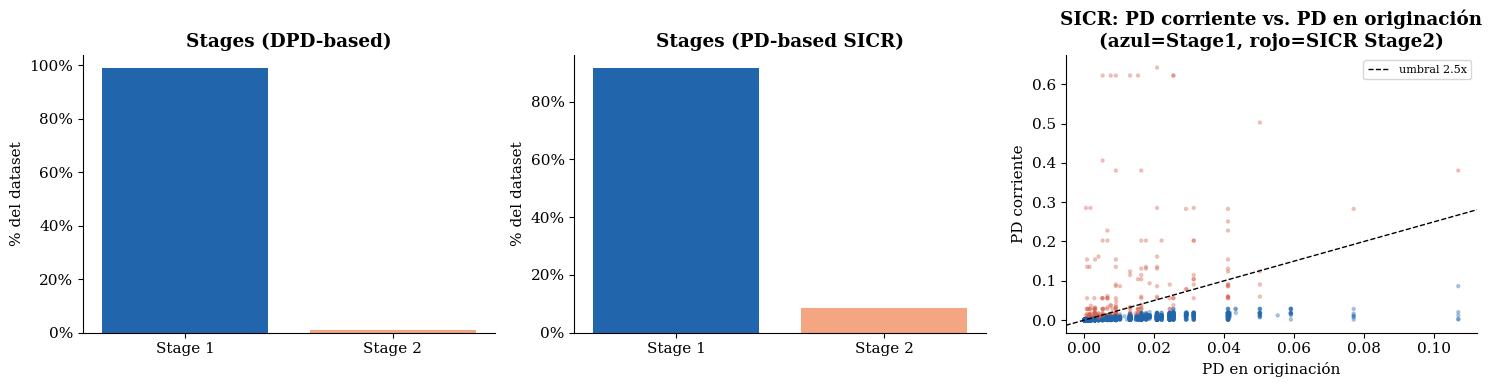


Reclasificaciones SICR:
  Stage1(DPD)->Stage2(PD): 1,072,624
  Stage2(DPD)->Stage1(PD): 0


In [35]:
# ── Comparar distribución de stages: DPD-based vs PD-based SICR ─────────────────────
import pandas as _pd
ds = _pd.read_parquet(DATA_DIR / 'dataset_modelado.parquet',
                      columns=['ifrs9_stage', 'ifrs9_stage_sicr',
                               'pd_origination', 'pd_current', 'sicr_pd_flag'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Comparativa de stages
for ax, col, titulo in zip(
    axes[:2],
    ['ifrs9_stage', 'ifrs9_stage_sicr'],
    ['Stages (DPD-based)', 'Stages (PD-based SICR)'],
):
    dist = ds[col].value_counts().sort_index()
    ax.bar([f'Stage {s}' for s in dist.index], dist.values / len(ds) * 100,
           color=['#2166ac', '#f4a582', '#d6604d'][:len(dist)])
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('% del dataset')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Scatter PD origination vs PD current (muestra aleatoria)
sample = ds[['pd_origination', 'pd_current', 'sicr_pd_flag']].dropna().sample(
    min(5000, len(ds)), random_state=42)
colores = sample['sicr_pd_flag'].map({0: '#2166ac', 1: '#d6604d'})
axes[2].scatter(sample['pd_origination'], sample['pd_current'],
                c=colores, alpha=0.3, s=5)
axes[2].axline((0,0), slope=2.5, color='k', linestyle='--', linewidth=1,
               label='umbral 2.5x')
axes[2].set_xlabel('PD en originación')
axes[2].set_ylabel('PD corriente')
axes[2].set_title('SICR: PD corriente vs. PD en originación\n'
                  '(azul=Stage1, rojo=SICR Stage2)', fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'sicr_pd_comparison.png', dpi=150)
plt.show()

# Tabla resumen
print('\nReclasificaciones SICR:')
print(f"  Stage1(DPD)->Stage2(PD): {((ds['ifrs9_stage']==1)&(ds['ifrs9_stage_sicr']==2)).sum():,}")
print(f"  Stage2(DPD)->Stage1(PD): {((ds['ifrs9_stage']==2)&(ds['ifrs9_stage_sicr']==1)).sum():,}")


## 8. Paso 5 – Calibración Lifetime PD (`05_calibracion_lifetime.py`)
Genera la curva de PD marginal por loan age (Lifetime PD para Stage 2).


In [36]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m05", SRC_DIR / "05_calibracion_lifetime.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
m.main()


PASO 5 – Calibración PIT y Lifetime PD


Modelo cargado: modelo_xgboost.joblib

  Calculando PD marginal por antigüedad del préstamo...


  Edades cubiertas: 0 a 109 meses

  Calculando Lifetime PD acumulada...

  === Puntos de referencia de la curva ===
    Edad  12 meses: PD_marginal=0.8092% | Lifetime_PD=8.8750%
    Edad  24 meses: PD_marginal=0.8765% | Lifetime_PD=17.8120%
    Edad  36 meses: PD_marginal=0.7508% | Lifetime_PD=25.6307%
    Edad  60 meses: PD_marginal=0.4275% | Lifetime_PD=34.9928%
    Edad 120 meses: PD_marginal=0.2205% | Lifetime_PD=44.4090%
    Edad 240 meses: PD_marginal=0.2205% | Lifetime_PD=44.4090%

  Tabla guardada: C:\Users\sebat\Tesis Maestria\data\FreddieMAC\outputs\tablas\curva_pd_lifetime.csv


  Gráfico guardado: C:\Users\sebat\Tesis Maestria\data\FreddieMAC\outputs\figuras\curva_pd_lifetime.png
Paso 5 completado.



,loan_age,pd_marginal,pd_lifetime_acum,n_obs
0,0,0.0042,0.0042,368433
1,1,0.0061,0.0102,392409
2,2,0.0068,0.0170,397707
3,3,0.0069,0.0238,393850
4,4,0.0070,0.0306,389058
...,...,...,...,...
105,105,0.0028,0.4383,5582
106,106,0.0025,0.4397,4395
107,107,0.0029,0.4413,3307
108,108,0.0027,0.4429,1860


,loan_age,pd_marginal,pd_lifetime_acum,n_obs
0,0,0.0042,0.0042,368433
1,1,0.0061,0.0102,392409
2,2,0.0068,0.0170,397707
3,3,0.0069,0.0238,393850
4,4,0.0070,0.0306,389058
5,5,0.0071,0.0375,382312
6,6,0.0074,0.0446,375474
7,7,0.0075,0.0518,367469
8,8,0.0077,0.0591,359619
9,9,0.0078,0.0665,351635


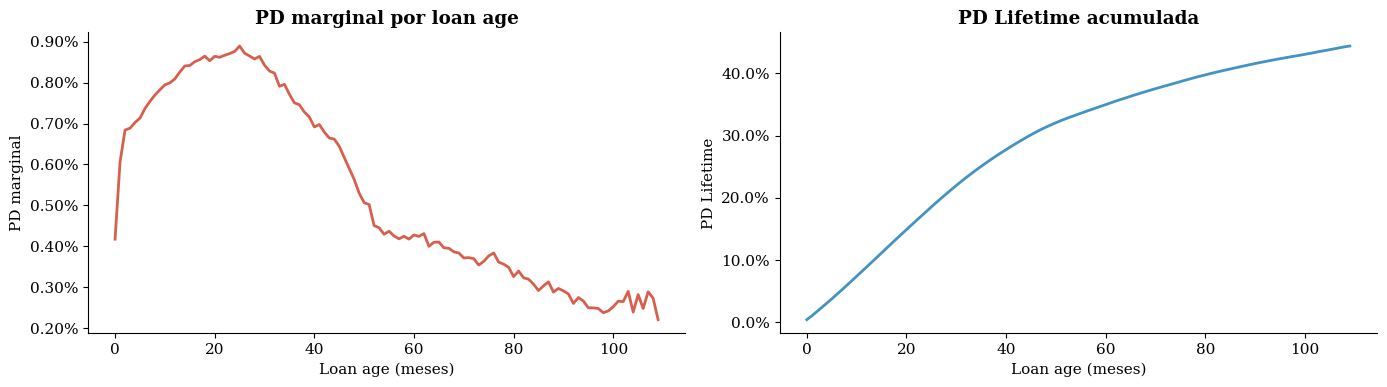

In [37]:
# ── Curva Lifetime PD ────────────────────────────────────────────────────────
curva = pd.read_csv(TABLAS_PATH / "curva_pd_lifetime.csv")
display(curva.head(12))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(curva.iloc[:,0], curva.iloc[:,1], color="#d6604d", linewidth=2)
axes[0].set_title("PD marginal por loan age", fontweight="bold")
axes[0].set_xlabel("Loan age (meses)")
axes[0].set_ylabel("PD marginal")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

if curva.shape[1] >= 3:
    axes[1].plot(curva.iloc[:,0], curva.iloc[:,2], color="#4393c3", linewidth=2)
    axes[1].set_title("PD Lifetime acumulada", fontweight="bold")
    axes[1].set_xlabel("Loan age (meses)")
    axes[1].set_ylabel("PD Lifetime")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()


## 8b. Paso 5b – Ponderación de Escenarios Macroeconómicos (IFRS 9 5.5.17c)

Implementa la ponderación de múltiples escenarios requerida por IFRS 9 y BIS d350:  

| Escenario | Peso | HPI | Desempleo | Fed Funds |
|---|---|---|---|---|
| Base | 50% | sin cambio | sin cambio | sin cambio |
| Pesimista | 30% | -25% | +4pp | -2.5pp |
| Optimista | 20% | +2% | -1pp | sin cambio |

ECL\_final = 0.50 × ECL\_base + 0.30 × ECL\_pesimista + 0.20 × ECL\_optimista  

> Requiere haber ejecutado Paso 0 (datos macro) y Paso 4 (modelo XGBoost).


In [38]:
macro_path = DATA_DIR / 'macro' / 'macro_monthly.parquet'
if macro_path.exists():
    import importlib.util as _iu
    spec = _iu.spec_from_file_location('m05b', SRC_DIR / '05b_scenario_weighting.py')
    m = _iu.module_from_spec(spec)
    sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                                # clases definidas en este modulo (p.ej.
                                # ModeloCalibraado, _ModeloOrigCal); sin esto
                                # joblib.dump() falla con PicklingError.
    spec.loader.exec_module(m)
    ecl_df = m.main()
else:
    print('Datos macro no disponibles – paso 5b omitido.')
    ecl_df = None


Datos macro no disponibles – paso 5b omitido.


In [39]:
# ── Resultados de escenarios y ECL ponderado ──────────────────────────────────────────────
from config import TABLAS_PATH
ecl_path = TABLAS_PATH / 'ecl_by_scenario.csv'
if ecl_path.exists():
    ecl_tbl = pd.read_csv(ecl_path)
    display(ecl_tbl.style.format({
        'peso': '{:.0%}',
        'pd_media_12m': '{:.4%}',
        'pd_lifetime_max': '{:.4%}',
        'ecl_ponderado': '{:.4%}',
    }))

from IPython.display import Image
fig_path = FIG_DIR / 'lifetime_pd_scenarios.png'
if fig_path.exists():
    print('--- Lifetime PD por escenario ---')
    display(Image(filename=str(fig_path), width=800))
else:
    print('lifetime_pd_scenarios.png no encontrado')


lifetime_pd_scenarios.png no encontrado


## 9. Paso 6 – Validación regulatoria (`06_validacion.py`)
Métricas exigidas por IFRS 9, EBA y BCBS: AUC/Gini, KS, Brier Score, Hosmer-Lemeshow, PSI, backtesting.


In [40]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m06", SRC_DIR / "06_validacion.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
m.main()


PASO 6 – Validación regulatoria del modelo PD



  [LOGISTICA]
    AUC        = 0.8647
    Gini       = 0.7295
    KS         = 0.5464
    Brier      = 0.0028
    HL p-valor = 0.0000
    PSI        = 0.2210 (monitorear)



  [XGBOOST]
    AUC        = 0.8540
    Gini       = 0.7080
    KS         = 0.5450
    Brier      = 0.0028
    HL p-valor = 0.0000
    PSI        = 0.3327 (INESTABLE)



  [RANDOM_FOREST]
    AUC        = 0.8560
    Gini       = 0.7121
    KS         = 0.5571
    Brier      = 0.0028
    HL p-valor = 0.0000
    PSI        = 0.3644 (INESTABLE)

  Tabla de métricas guardada: C:\Users\sebat\Tesis Maestria\data\FreddieMAC\outputs\tablas\validacion_metricas.csv


  Gráfico ROC guardado.


...

  Matriz de transición trimestral (Stage t -> Stage t+3m):
stage_q3         1      2      3
ifrs9_stage                     
1           0.9914 0.0077 0.0010
2           0.4896 0.2993 0.2111
3           0.2569 0.0433 0.6998

  Stage 1->3 directo (sin pasar por Stage 2): 0.1000%
  Cure rate trimestral (Stage 2->1): 48.9600%


  PSI distribución de stages (train vs test): 0.0265
  Guardado: transition_matrix_observed.csv, cure_rates_quarterly.csv

  [Backtesting Lifetime PD vs. defaults observados]


  MAE predicho vs. observado: 18.1875%
  Ratio medio predicho/observado: 10.724 (>1=conservador, <1=subestimación)


  Gráfico guardado: C:\Users\sebat\Tesis Maestria\data\FreddieMAC\outputs\figuras\lifetime_pd_backtest.png
  Tabla guardada:   lifetime_pd_backtest_by_vintage.csv

Paso 6 completado.



,AUC,Gini,KS,Brier,HL_pvalor,PSI,PSI_estado
Modelo,,,,,,,
logistica,0.8647,0.7295,0.5464,0.0028,0.0000,0.2210,monitorear
xgboost,0.8540,0.7080,0.5450,0.0028,0.0000,0.3327,INESTABLE
random_forest,0.8560,0.7121,0.5571,0.0028,0.0000,0.3644,INESTABLE


In [41]:
# ── Métricas de validación ────────────────────────────────────────────────────
met = pd.read_csv(TABLAS_PATH / "validacion_metricas.csv")
display(met)

# ── Backtesting ───────────────────────────────────────────────────────────────
bkt = pd.read_csv(TABLAS_PATH / "validacion_backtesting.csv")
display(bkt)


,Modelo,AUC,Gini,KS,Brier,HL_pvalor,PSI,PSI_estado
0,logistica,0.8647,0.7295,0.5464,0.0028,0.0000,0.2210,monitorear
1,xgboost,0.8540,0.7080,0.5450,0.0028,0.0000,0.3327,INESTABLE
2,random_forest,0.8560,0.7121,0.5571,0.0028,0.0000,0.3644,INESTABLE


,decil,n,defaults,pd_predicha,pd_observada,diferencia,modelo
0,1,42025,3,0.0004,0.0001,0.0003,logistica
1,2,47335,10,0.0007,0.0002,0.0004,logistica
2,3,49317,29,0.0013,0.0006,0.0007,logistica
3,4,26366,10,0.0016,0.0004,0.0013,logistica
4,5,66853,59,0.0023,0.0009,0.0014,logistica
5,6,39690,50,0.0037,0.0013,0.0024,logistica
6,7,18105,40,0.0043,0.0022,0.0021,logistica
7,8,43821,141,0.0059,0.0032,0.0027,logistica
8,9,38061,146,0.0088,0.0038,0.0050,logistica
9,10,40492,751,0.0368,0.0185,0.0183,logistica


### 9b. Backtesting de transiciones de stages (EBA GL 38/66)

Matriz de transición trimestral (Stage t → Stage t+3m):


,1,2,3
ifrs9_stage,,,
1,99.1400%,0.7700%,0.1000%
2,48.9600%,29.9300%,21.1100%
3,25.6900%,4.3300%,69.9800%


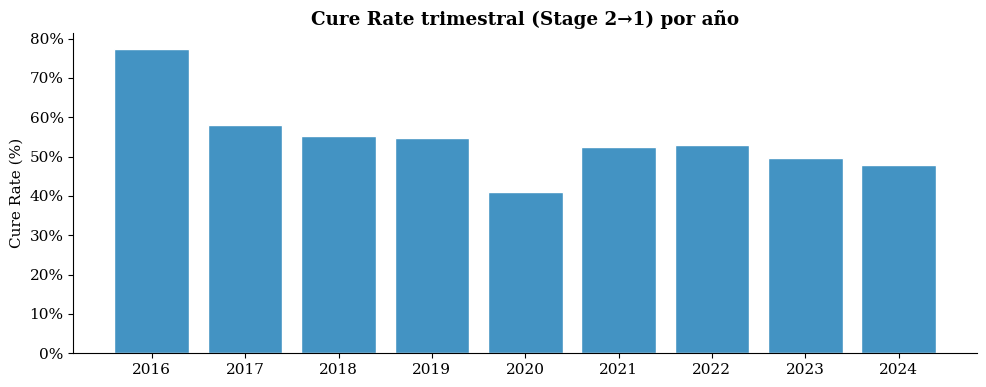

In [42]:
# ── Matriz de transición trimestral observada ─────────────────────────────────────────────
from config import TABLAS_PATH
trans_path = TABLAS_PATH / 'transition_matrix_observed.csv'
cure_path  = TABLAS_PATH / 'cure_rates_quarterly.csv'

if trans_path.exists():
    trans = pd.read_csv(trans_path, index_col=0)
    print('Matriz de transición trimestral (Stage t → Stage t+3m):')
    display(trans.style.format('{:.4%}').background_gradient(cmap='Blues'))

if cure_path.exists():
    cure = pd.read_csv(cure_path)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(cure['year'].astype(str), cure['cure_rate'] * 100,
           color='#4393c3', edgecolor='white')
    ax.set_title('Cure Rate trimestral (Stage 2→1) por año', fontweight='bold')
    ax.set_ylabel('Cure Rate (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()
else:
    print('Ejecutar paso 6 para generar backtesting de transiciones')


### 9c. Backtesting Lifetime PD vs. defaults observados (EBA GL 66)

Tasa de default acumulada OBSERVADA por vintage y horizonte (%):


horizon_months,12,24,36,48,60
vintage_year,,,,,
2016,0.3120,0.7390,0.9030,3.4650,6.3020
2017,0.6040,0.9560,4.3400,8.2810,7.9860
2018,0.4000,3.9860,9.5720,9.7310,9.1740
2019,2.8160,7.3430,7.7800,7.2360,7.1750
2020,1.2740,1.5780,1.6130,1.5870,5.1920
2022,0.7460,1.5350,1.9750,NaN,NaN
2023,0.6170,1.4680,NaN,NaN,NaN
2024,0.7740,NaN,NaN,NaN,NaN



Lifetime PD PREDICHA a los mismos horizontes (%):


horizon_months,12,24,36,48,60
vintage_year,,,,,
2016,8.8750,17.8120,25.6310,31.3680,34.9930
2017,8.8750,17.8120,25.6310,31.3680,34.9930
2018,8.8750,17.8120,25.6310,31.3680,34.9930
2019,8.8750,17.8120,25.6310,31.3680,34.9930
2020,8.8750,17.8120,25.6310,31.3680,34.9930
2022,8.8750,17.8120,25.6310,NaN,NaN
2023,8.8750,17.8120,NaN,NaN,NaN
2024,8.8750,NaN,NaN,NaN,NaN



MAE promedio: 18.1875%
Ratio predicho/observado promedio: 10.724


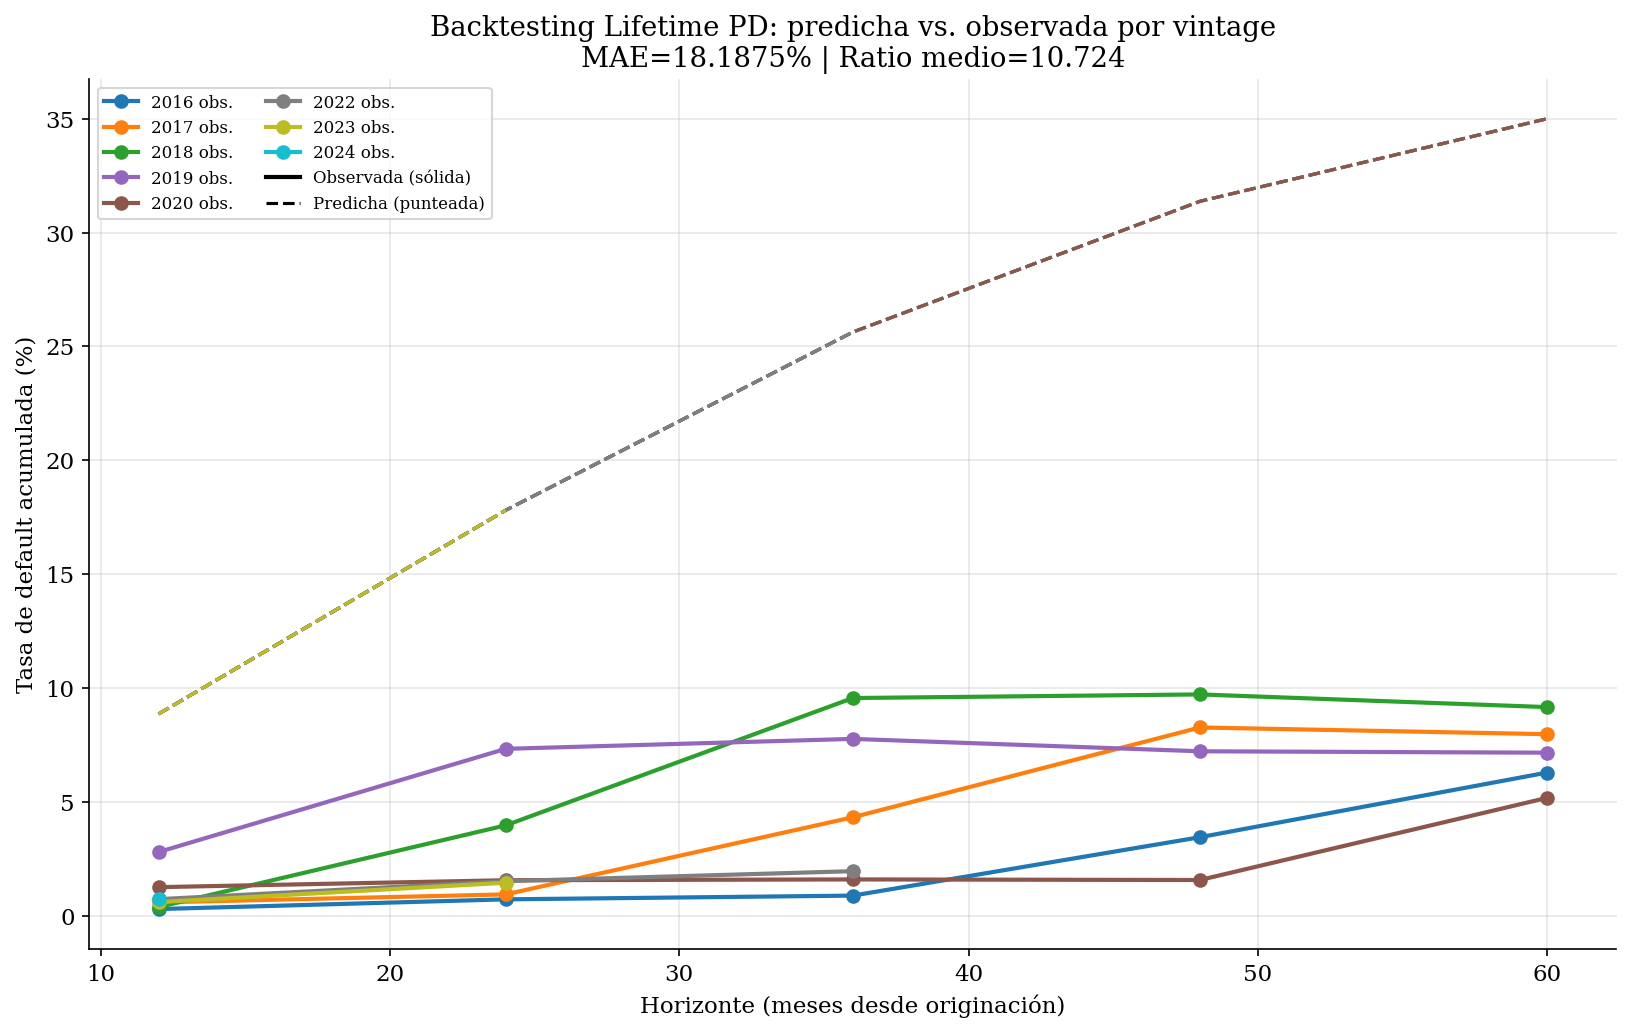

In [43]:
# ── Lifetime PD predicha vs. observada por vintage ──────────────────────────────
bt_path = TABLAS_PATH / 'lifetime_pd_backtest_by_vintage.csv'
if bt_path.exists():
    bt = pd.read_csv(bt_path)
    pivot_obs  = bt.pivot(index='vintage_year', columns='horizon_months',
                           values='obs_default_rate').mul(100).round(3)
    pivot_pred = bt.pivot(index='vintage_year', columns='horizon_months',
                           values='pred_lifetime_pd').mul(100).round(3)
    print('Tasa de default acumulada OBSERVADA por vintage y horizonte (%):')
    display(pivot_obs)
    print('\nLifetime PD PREDICHA a los mismos horizontes (%):')
    display(pivot_pred)
    print(f"\nMAE promedio: {bt['abs_error'].mean():.4%}")
    print(f"Ratio predicho/observado promedio: {bt['ratio_pred_obs'].mean():.3f}")

from IPython.display import Image
fig_bt = FIG_DIR / 'lifetime_pd_backtest.png'
if fig_bt.exists():
    display(Image(filename=str(fig_bt), width=900))
else:
    print('lifetime_pd_backtest.png no encontrado – ejecutar paso 6')


--- validacion_roc.png ---


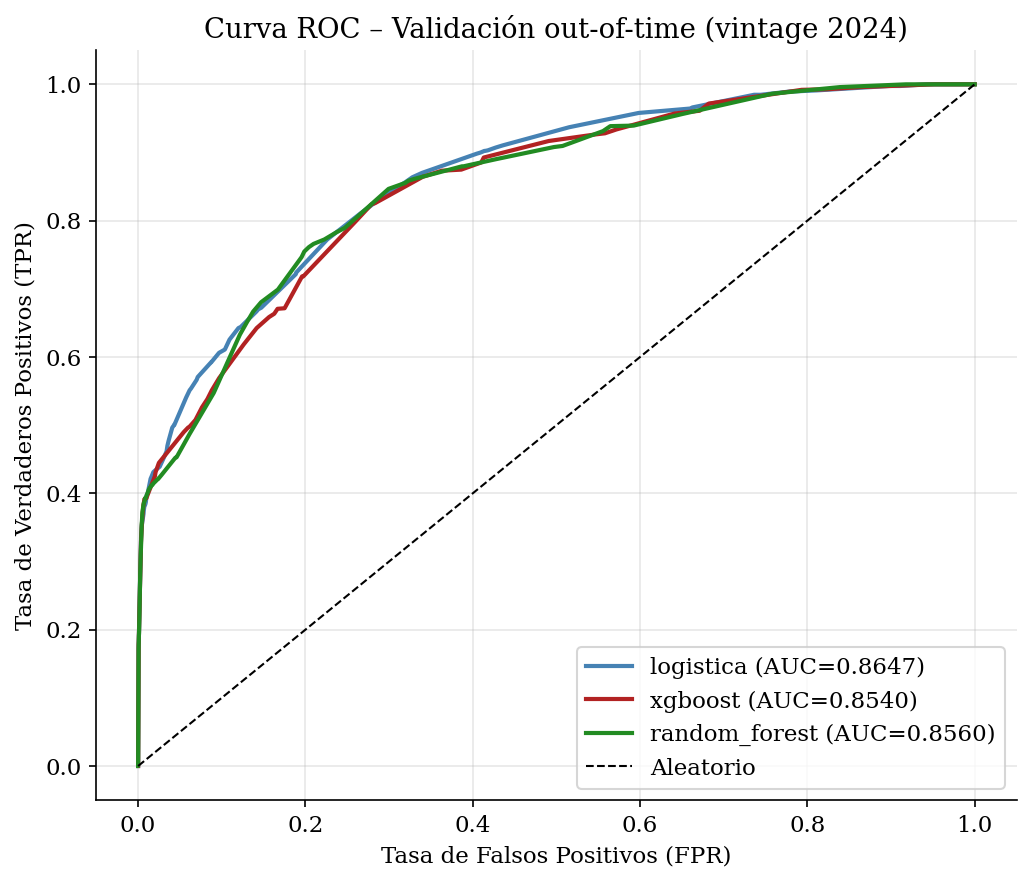

--- validacion_backtesting.png ---


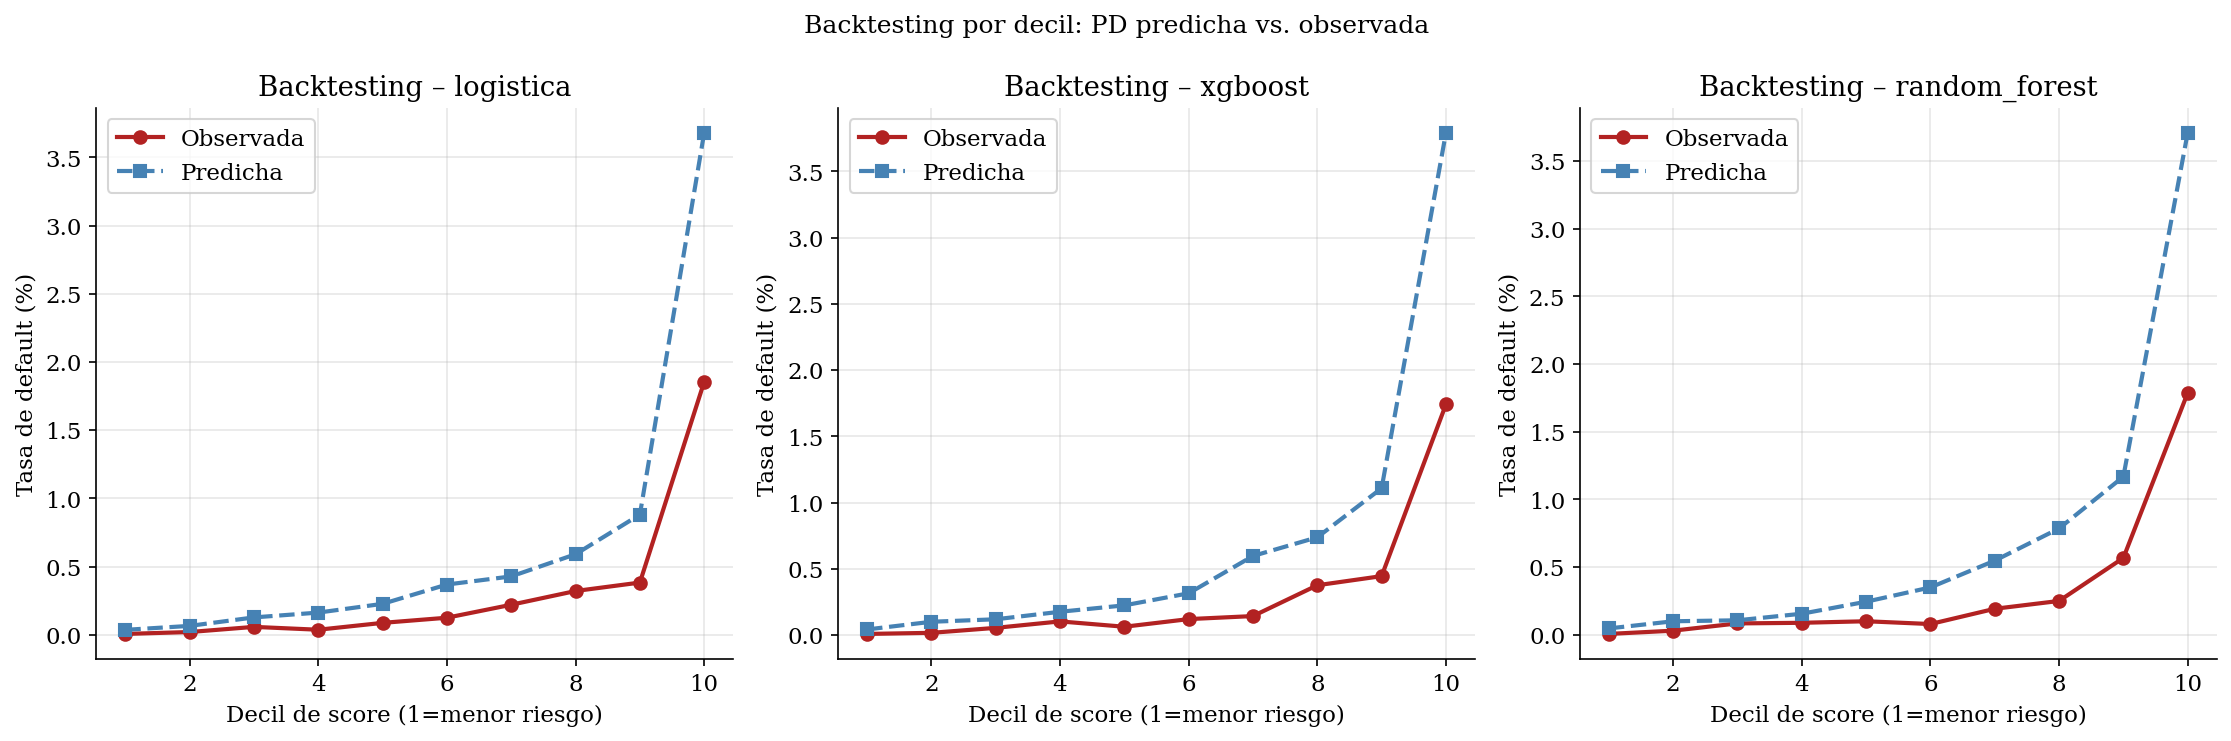

In [44]:
# ── Mostrar figuras de validación ────────────────────────────────────────────
from IPython.display import Image
for img_name in ["validacion_roc.png", "validacion_backtesting.png"]:
    img_path = FIG_DIR / img_name
    if img_path.exists():
        print(f"--- {img_name} ---")
        display(Image(filename=str(img_path), width=750))


## 10. Paso 7 – Explicabilidad SHAP (`07_explicabilidad.py`)
Análisis global (beeswarm, bar plot, importancia por gain) y local (waterfall por préstamo).


In [45]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m07", SRC_DIR / "07_explicabilidad.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
m.main()


PASO 7 – Explicabilidad del modelo (SHAP)


Modelo XGBoost cargado: modelo_xgboost.joblib


Muestra para SHAP: 4,999 observaciones
  Calculando SHAP values (XGBoost)...


  Gráfico SHAP summary guardado.


  Gráfico SHAP bar guardado.
  Tabla SHAP guardada: importancia_shap_xgboost.csv

  Explicando préstamo de mayor riesgo (PD=62.2248%)...


  Waterfall plot del préstamo 426 guardado.
  Explicando préstamo de menor riesgo (PD=0.0000%)...


  Waterfall plot del préstamo 39 guardado.
  Gráfico importancia Gain guardado.

Paso 7 completado.



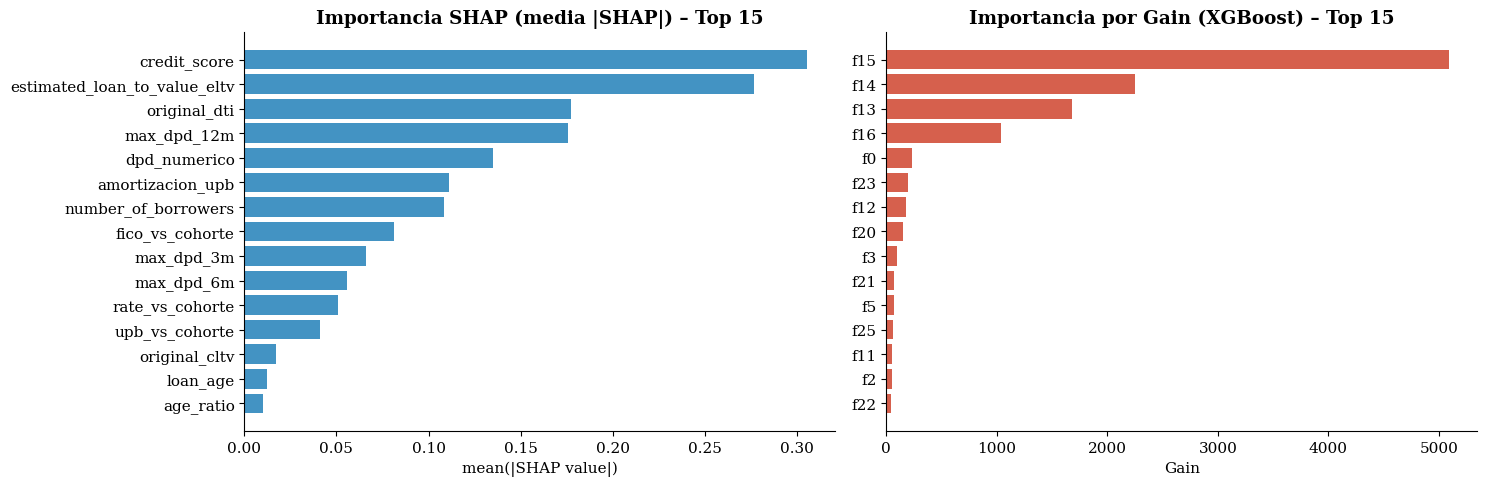

In [46]:
# ── Importancia SHAP ──────────────────────────────────────────────────────────
shap_imp = pd.read_csv(TABLAS_PATH / "importancia_shap_xgboost.csv")
gain_imp = pd.read_csv(TABLAS_PATH / "importancia_gain_xgboost.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_shap = shap_imp.head(15).sort_values(shap_imp.columns[1])
axes[0].barh(top_shap.iloc[:,0], top_shap.iloc[:,1], color="#4393c3")
axes[0].set_title("Importancia SHAP (media |SHAP|) – Top 15", fontweight="bold")
axes[0].set_xlabel("mean(|SHAP value|)")

top_gain = gain_imp.head(15).sort_values(gain_imp.columns[1])
axes[1].barh(top_gain.iloc[:,0], top_gain.iloc[:,1], color="#d6604d")
axes[1].set_title("Importancia por Gain (XGBoost) – Top 15", fontweight="bold")
axes[1].set_xlabel("Gain")

plt.tight_layout()
plt.show()


--- shap_summary_xgboost.png ---


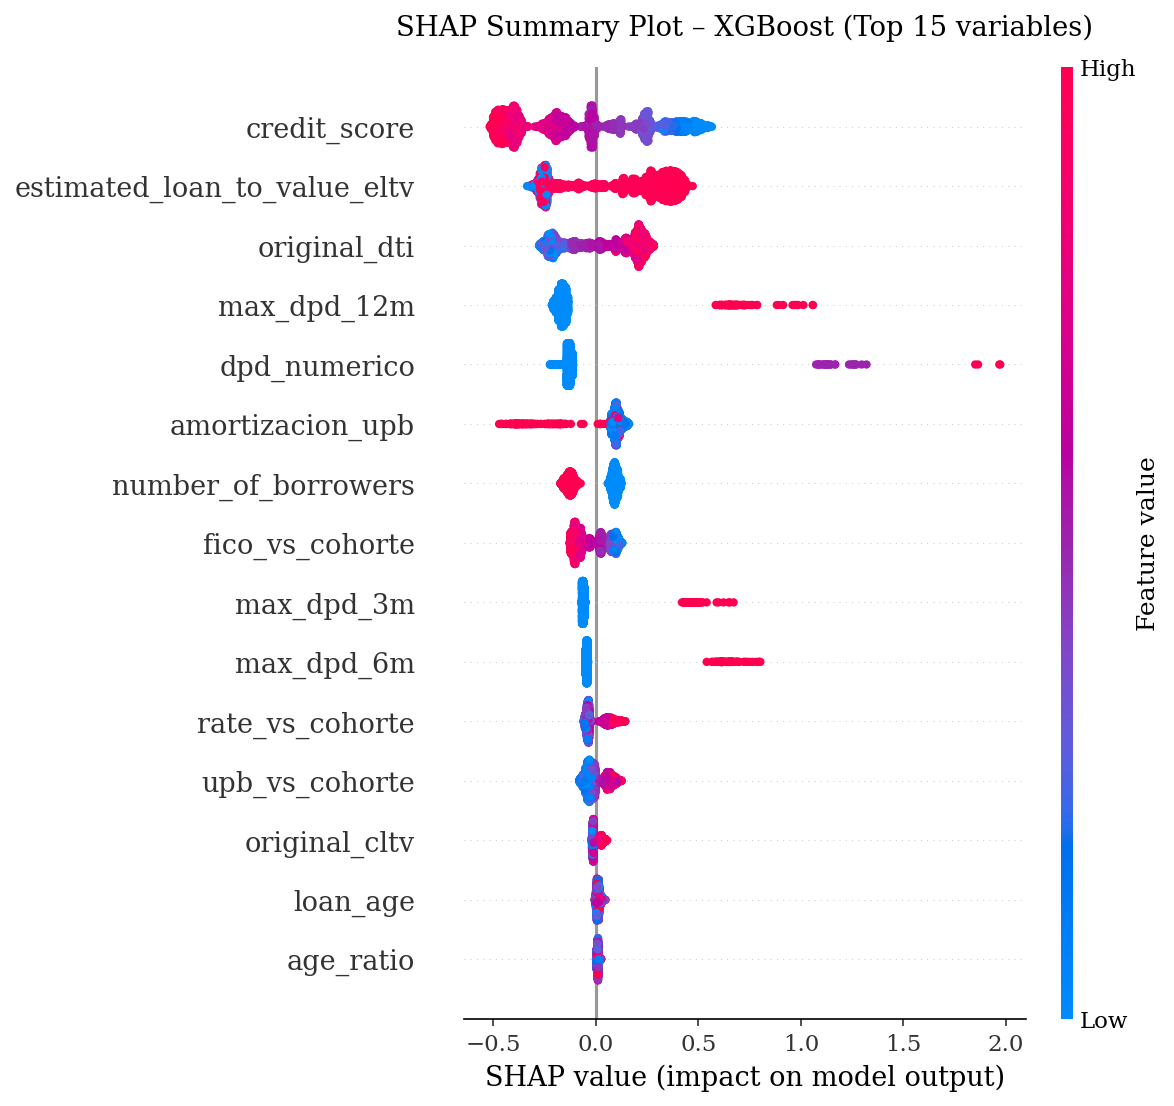

--- shap_barplot_xgboost.png ---


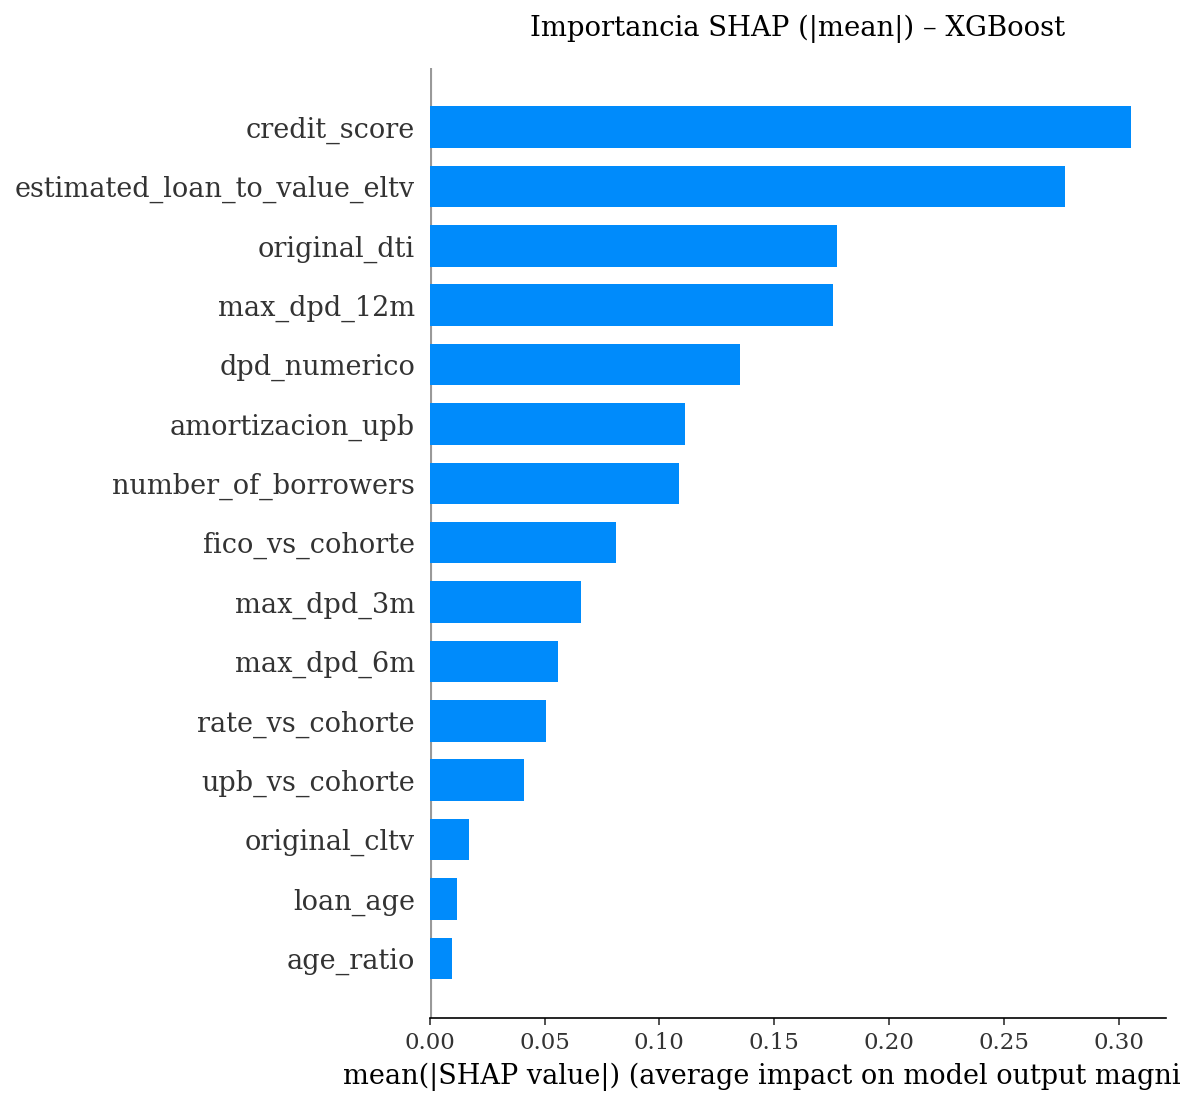

--- shap_waterfall_prestamo_39.png ---


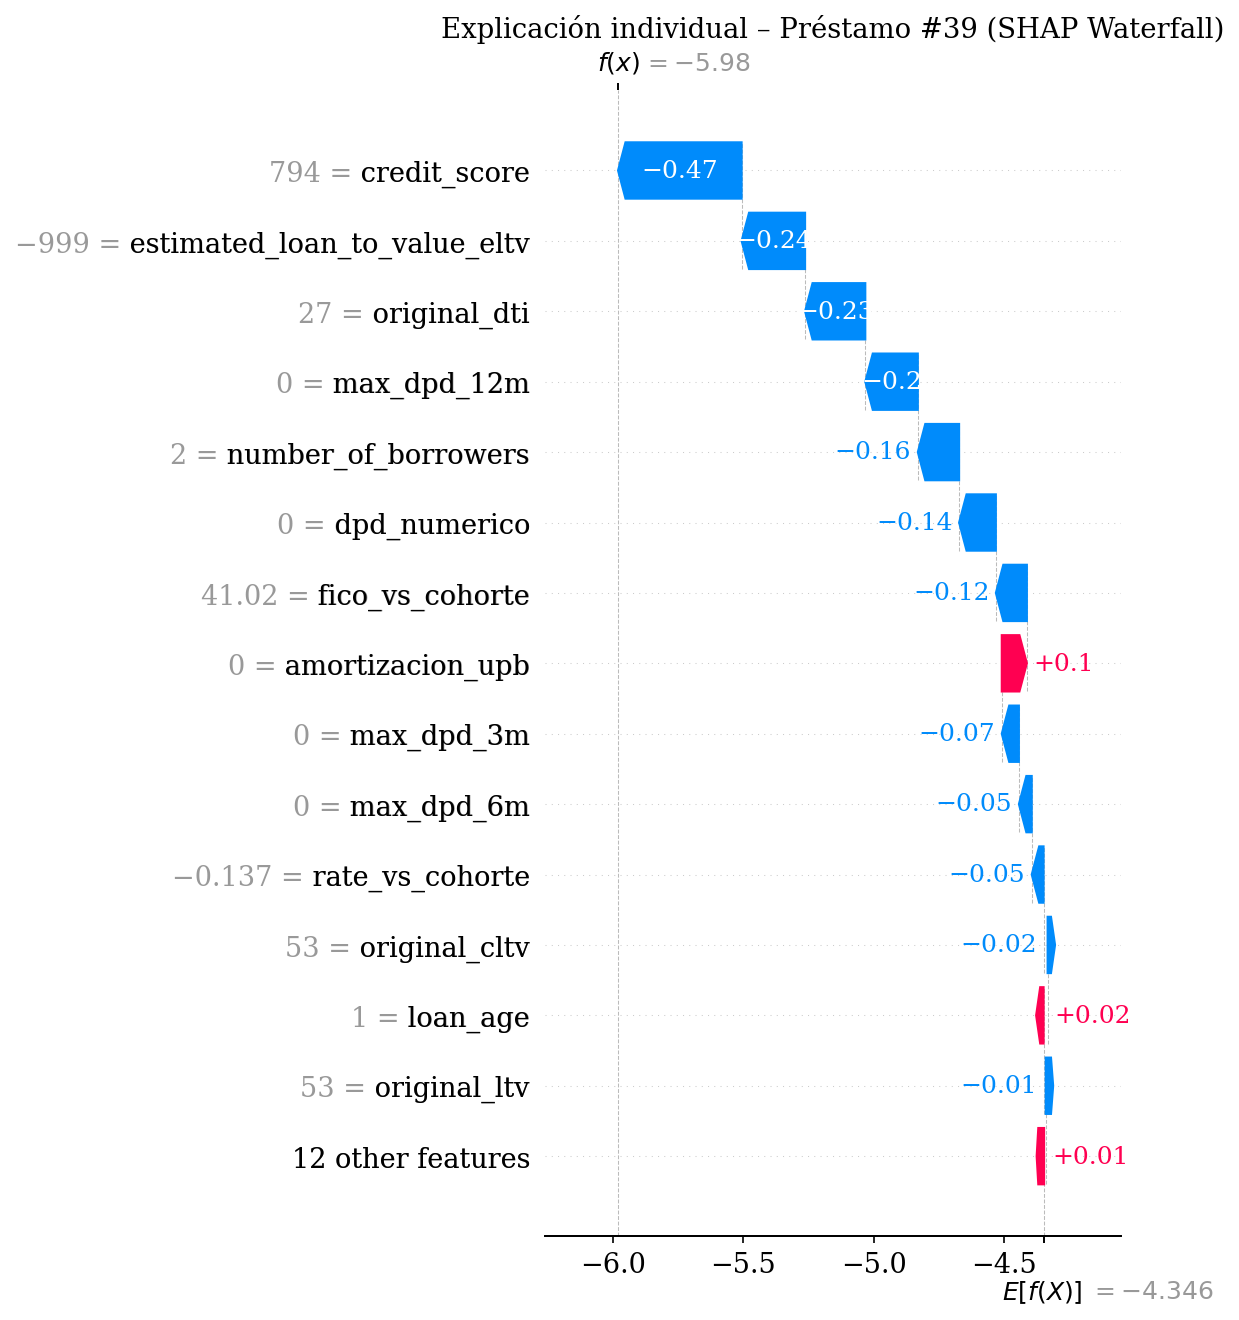

--- shap_waterfall_prestamo_426.png ---


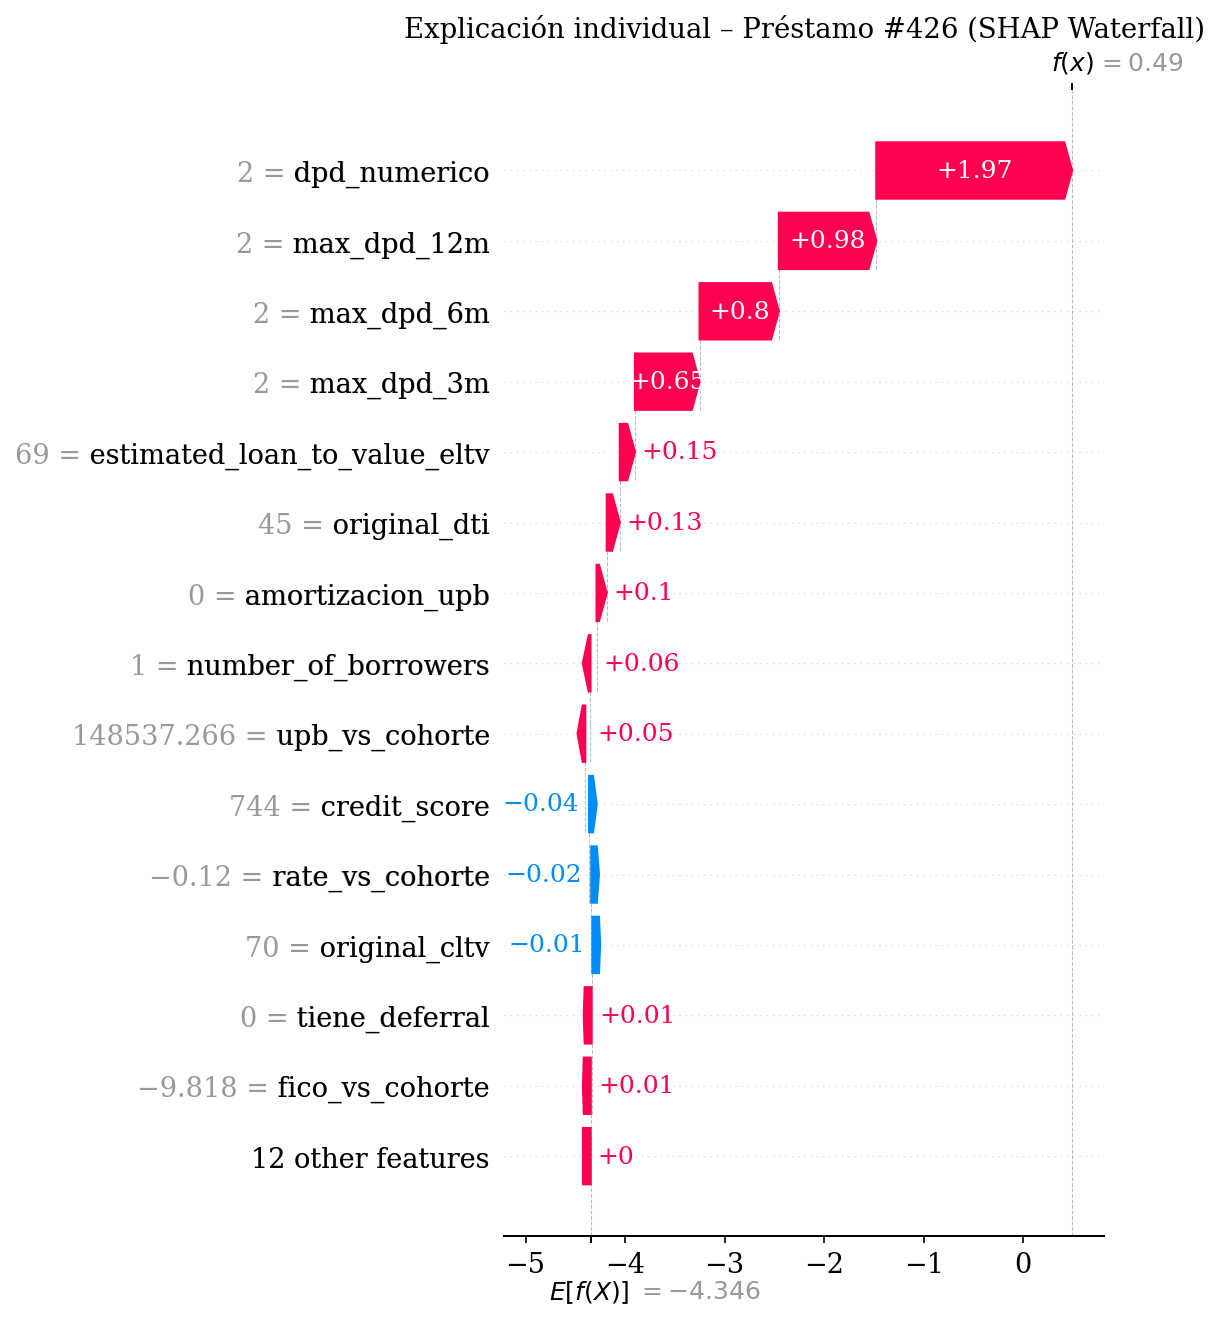

--- shap_waterfall_prestamo_4986.png ---


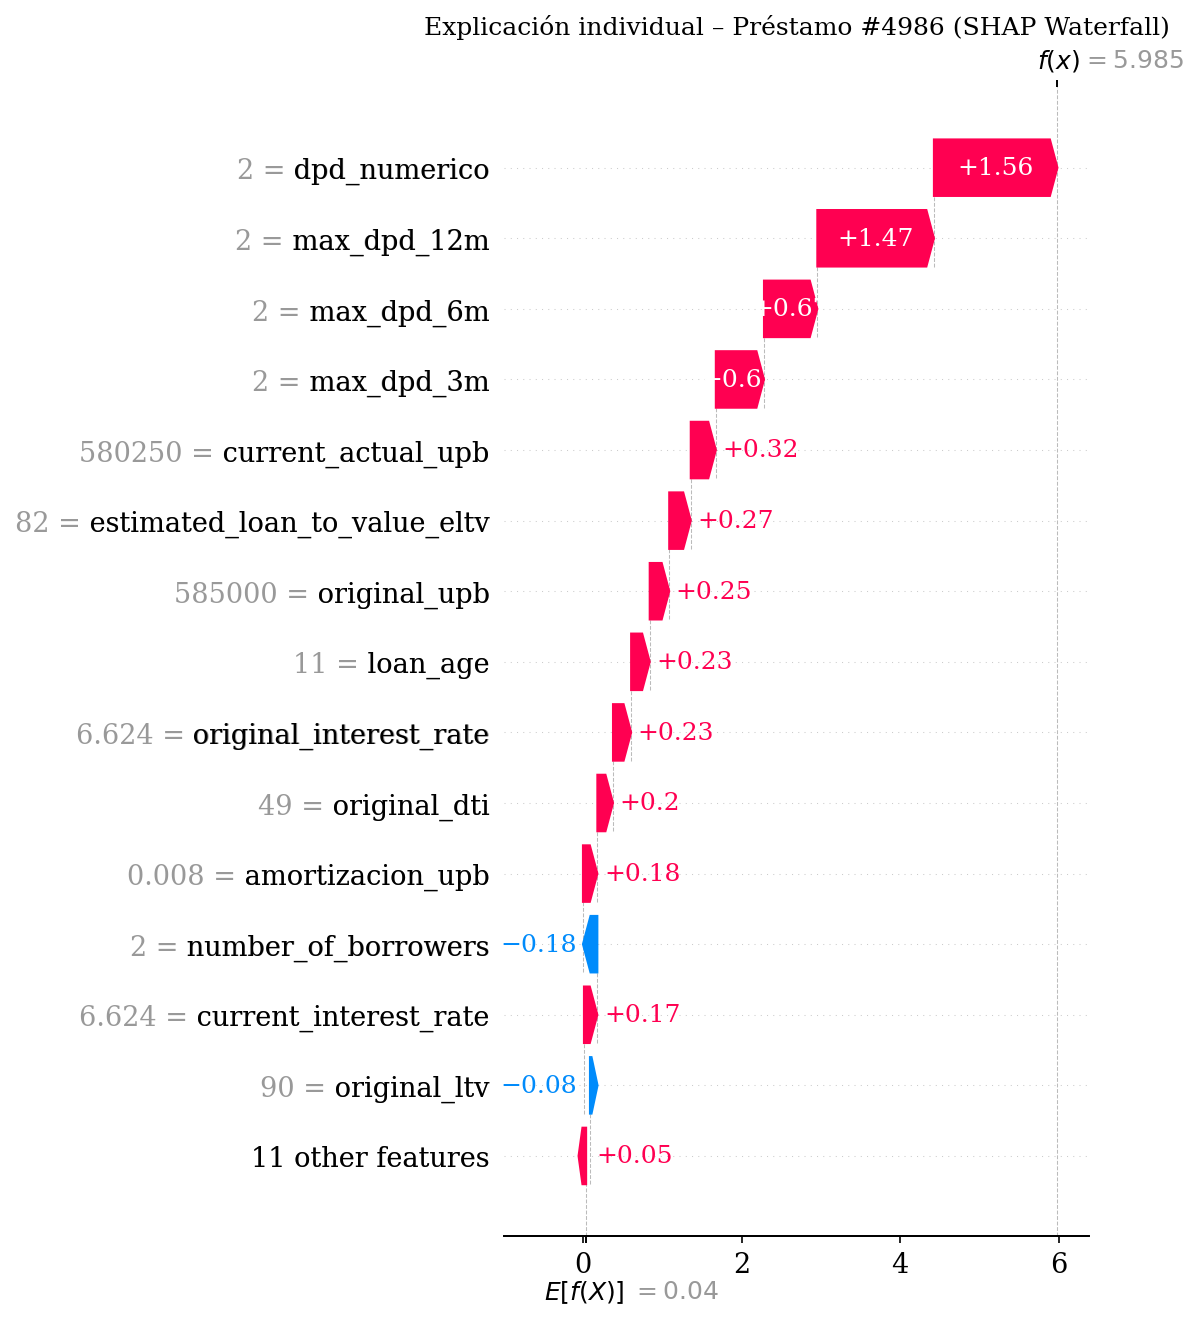

--- shap_waterfall_prestamo_503.png ---


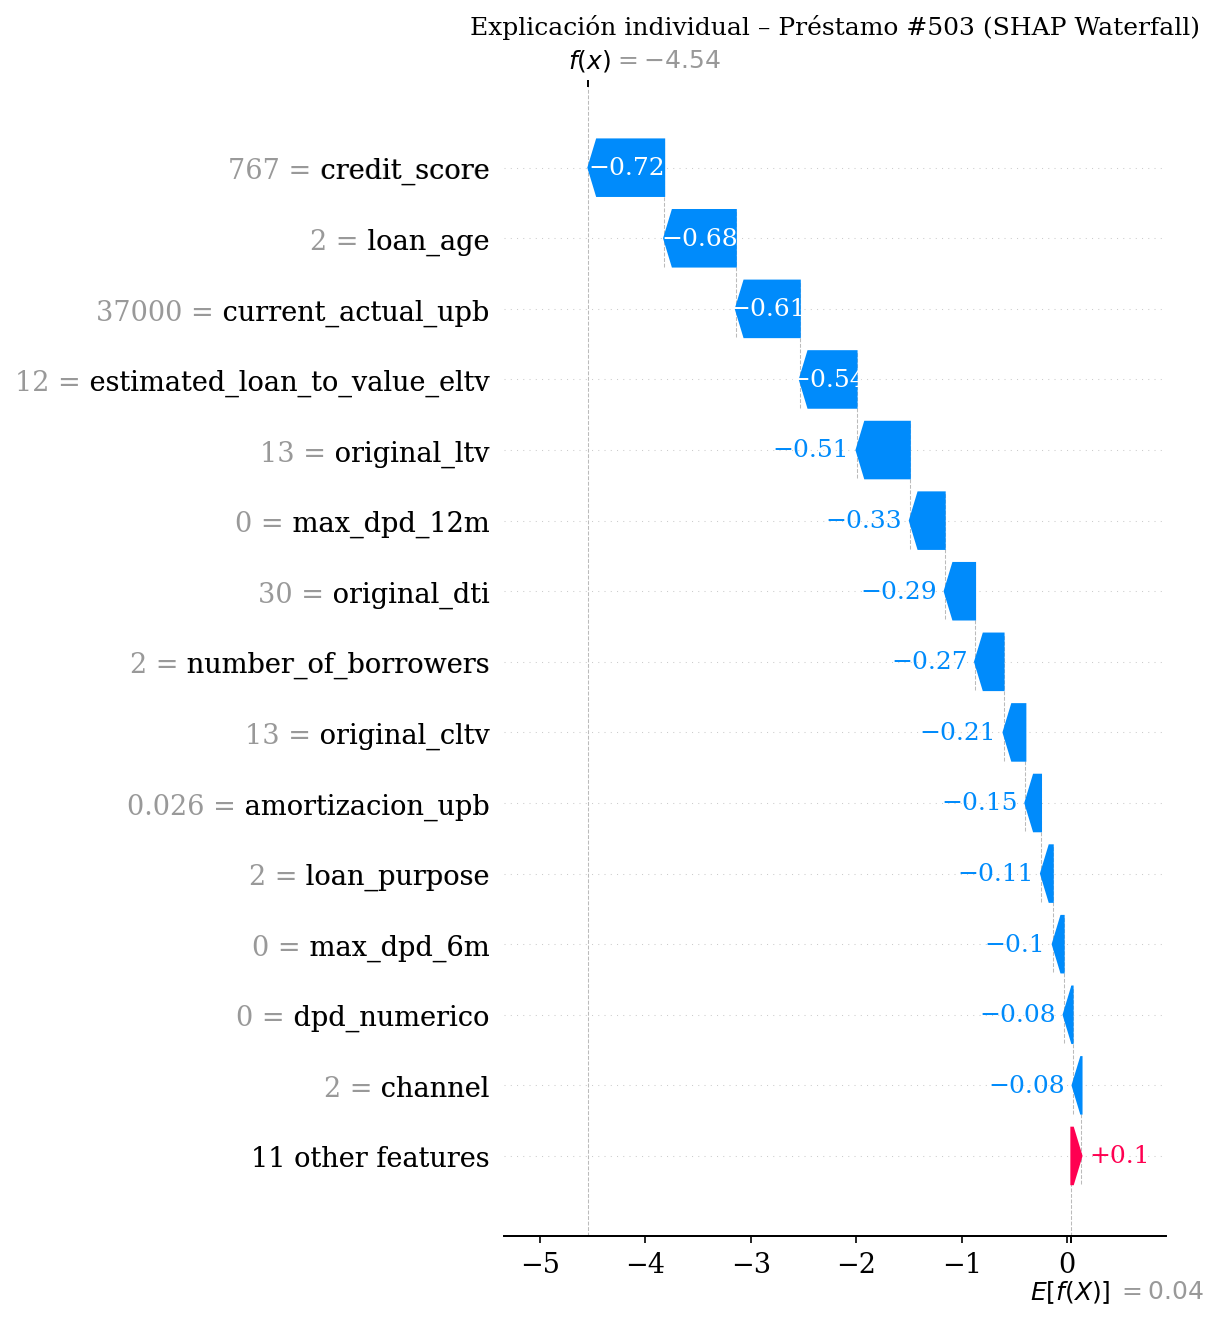

In [47]:
# ── Mostrar gráficos SHAP generados ──────────────────────────────────────────
from IPython.display import Image

for img_name in ["shap_summary_xgboost.png", "shap_barplot_xgboost.png"]:
    img_path = FIG_DIR / img_name
    if img_path.exists():
        print(f"--- {img_name} ---")
        display(Image(filename=str(img_path), width=750))

# Los waterfall plots individuales se nombran por el índice del préstamo dentro de la
# muestra SHAP (aleatoria en cada corrida) -> se descubren dinámicamente, no se hardcodea.
for img_path in sorted(FIG_DIR.glob("shap_waterfall_prestamo_*.png")):
    print(f"--- {img_path.name} ---")
    display(Image(filename=str(img_path), width=750))


## 12. Paso 6b - Segmentacion: validacion empirica (`06b_segmentacion.py`)
Respaldo cuantitativo del Control 3.6: discriminacion (AUC/Gini/KS), estabilidad (PSI), homogeneidad intra-segmento y heterogeneidad inter-segmento por dimension de segmentacion (banda de FICO, LTV, DTI, proposito, ocupacion, canal, tipo de propiedad).

> **Dependencia:** requiere el Paso 4 (modelo XGBoost entrenado).

In [48]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m06b", SRC_DIR / "06b_segmentacion.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
seg_metricas = m.main()


PASO 6b – Validación empírica de la segmentación (Control 3.6)


Dataset cargado: 14,481,471 filas


Dimensiones de segmentación evaluadas: 7

  [banda_fico]


segmento  n_test  defaults_test  tasa_def_test  AUC_test  KS_test    PSI
 660-699   42449            319         0.0075    0.7888   0.4711 1.0441
 700-739   80915            283         0.0035    0.7622   0.3900 0.8132
 740-779  130924            238         0.0018    0.8046   0.4522 0.6882
    780+  140311             95         0.0007    0.7806   0.4280 0.6968
    <660   17316            304         0.0176    0.7398   0.4025 1.4583
sin_dato     150              0         0.0000       NaN      NaN 5.1650


    Homogeneidad intra-segmento: 0/5 segmentos homogéneos (chi², alfa=0.05)


...

    Homogeneidad intra-segmento: 0/5 segmentos homogéneos (chi², alfa=0.05)


    Heterogeneidad inter-segmento: chi2=127.0 (gl=4) p=1.7e-26 V=0.0030 -> segmentos diferenciados



  Tablas guardadas: segmentacion_metricas.csv, segmentacion_homogeneidad.csv, segmentacion_heterogeneidad.csv, segmentacion_heterogeneidad_global.csv


  Figura guardada: segmentacion_curvas_default.png


  Figura guardada: segmentacion_discriminacion.png

  Segmentos reportables: 24/31
  AUC out-of-time mínimo por segmento : 0.7398
  AUC out-of-time mediano por segmento: 0.8403
  Segmentos con PSI > 0,25            : 21

Paso 6b completado.



,segmentacion,segmento,n_test,tasa_def_test,AUC_test,KS_test,PSI,PSI_estado
18,proposito,N (refi no cash-out),28067,0.0047,0.9333,0.7254,0.3988,INESTABLE
9,banda_ltv,<=60,78502,0.0017,0.9216,0.7013,0.2585,INESTABLE
6,banda_ltv,60-75,63453,0.0025,0.8998,0.6479,0.4582,INESTABLE
25,canal,R (retail),200593,0.0025,0.8848,0.6112,0.3580,INESTABLE
29,tipo_prop,PU (PUD),126968,0.0026,0.8818,0.5679,0.2744,INESTABLE
12,banda_dti,30-36,66335,0.0028,0.8791,0.6431,0.2334,monitorear
14,banda_dti,<=30,80483,0.0007,0.8689,0.5990,0.2364,monitorear
19,proposito,P (compra),332757,0.0027,0.8552,0.5483,0.2061,monitorear
21,ocupacion,P (primaria),377420,0.0032,0.8513,0.5376,0.3314,INESTABLE
30,tipo_prop,SF (unifamiliar),240202,0.0033,0.8452,0.5358,0.3931,INESTABLE


--- segmentacion_curvas_default.png ---


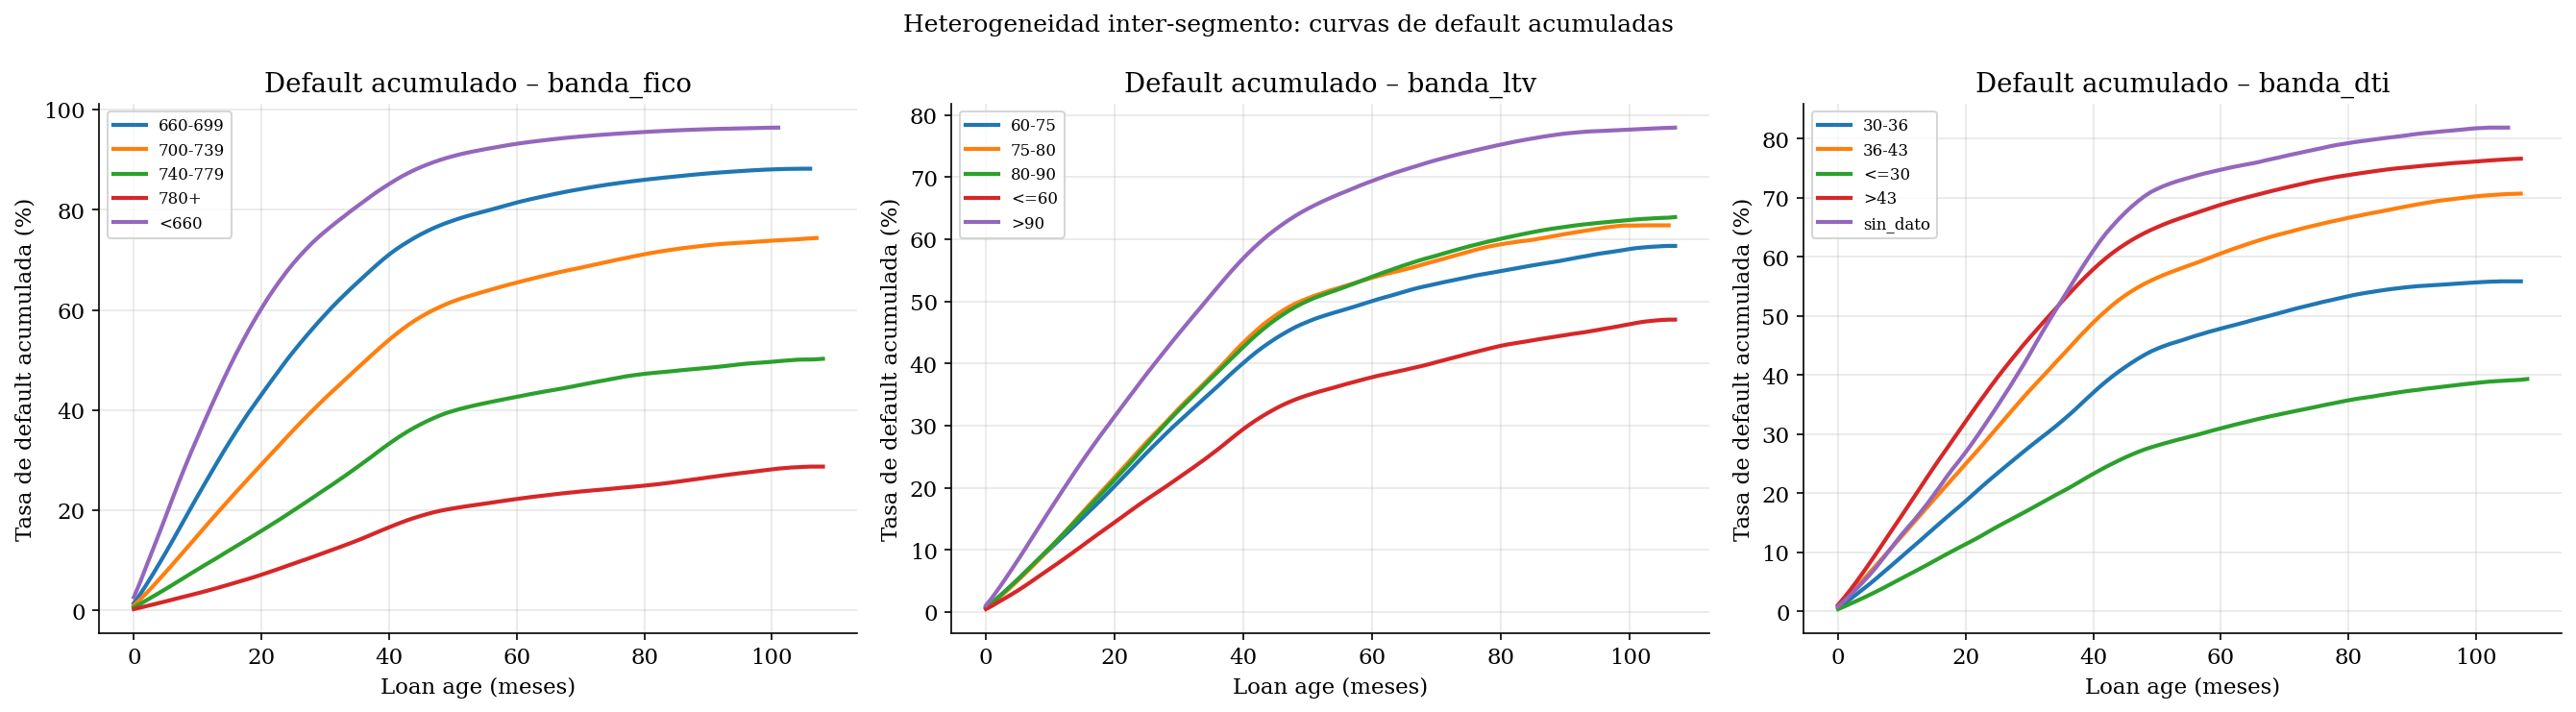

--- segmentacion_discriminacion.png ---


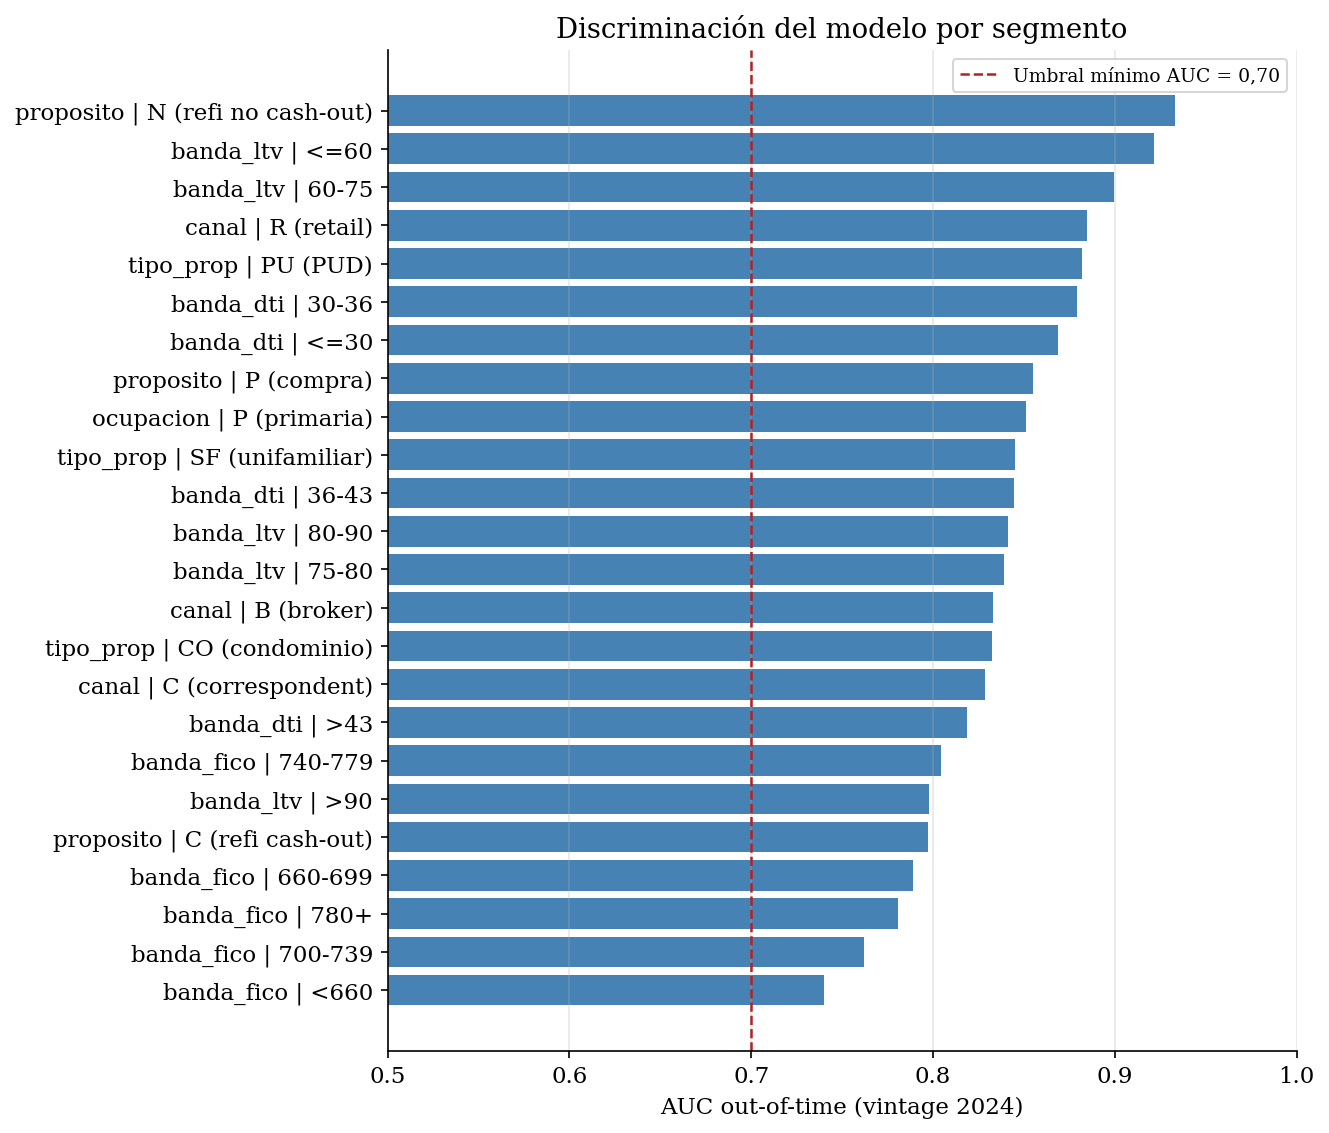

65154

In [49]:
# -- Segmentos reportables, ordenados por AUC out-of-time -----------------------
rep = seg_metricas[seg_metricas["reportable"]].sort_values("AUC_test", ascending=False)
display(rep[["segmentacion", "segmento", "n_test", "tasa_def_test",
             "AUC_test", "KS_test", "PSI", "PSI_estado"]])

from IPython.display import Image
for img_name in ["segmentacion_curvas_default.png", "segmentacion_discriminacion.png"]:
    img_path = FIG_DIR / img_name
    if img_path.exists():
        print(f"--- {img_name} ---")
        display(Image(filename=str(img_path), width=850))

del seg_metricas, rep
import gc; gc.collect()


## 13. Paso 8 - LGD y EAD (`08_lgd_ead.py`)
Controles 7.5 (supuestos de perdida total y curva de recuperacion), 8.1 (EAD por amortizacion teorica + prepago), 8.2 (CCF y alcance de exposiciones fuera de balance) y 8.6 (alcance cambiario).


In [50]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m08", SRC_DIR / "08_lgd_ead.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
_, ead_resumen = m.main()


PASO 8 – LGD y EAD (Controles 7.5, 8.1, 8.2, 8.6)

  [Episodios de default: workout y curación]


  Préstamos con al menos un evento de default: 13,708


      desenlace    n  workout_medio  workout_p95  proporcion
        abierto 2780        15.8737      56.0000      0.2028
         curado 6535        41.8739      57.0000      0.4767
      liquidado  269        21.2974      50.0000      0.0196
prepago/vencido 4124        11.7367      31.0000      0.3008

  Cure rate (probation 12 meses): 47.67%
  Exposiciones que superan el workout máximo (60 meses) sin resolución -> LGD = 100%: 58

  [LGD realizada]


  Registros de liquidación leídos: 178,511
  Exposiciones liquidadas por default: 269
  LGD media (simple)            : 24.82%
  LGD media descontada al EIR   : 22.57%
  LGD ponderada por exposición  : 19.83%
  LGD downturn (media + add-on) : 29.82%

  LGD por banda de LTV original:
banda_ltv   n  lgd_media  tasa_recuperacion
     <=60  10     0.2698             0.7302
    60-75  35     0.3135             0.6865
    75-80  22     0.3440             0.6560
    80-90  59     0.2454             0.7546
      >90 143     0.2171             0.7829

  Curva de recuperación por período de workout:
tramo  n  recuperacion_media  recuperacion_mediana  lgd_media  lgd_descontada_media    ead_media  recuperacion_marginal
  0-6 34              0.7856                0.9589     0.2144                0.2103 172,905.2368                    NaN
 7-12 55              0.8414                0.9413     0.1586                0.1534 147,306.6295                 0.0558
13-18 54              0.7545               

moneda_base                           USD
cartera_multidivisa                 False
horizonte_meses                        12
n_exposiciones_vivas             14424701
upb_actual_medio             229,359.8100
upb_teorico_12m_medio        227,892.6500
cpr_anual_media                    0.0086
interes_devengado_medio        2,525.8100
ead_proyectada_media         228,450.3800
ead_sobre_upb_actual               0.9960
ccf_off_balance                    0.0000
error_medio_amortizacion_pct       3.5290

  Tablas guardadas en outputs/tablas/ (lgd_*.csv, ead_*.csv, ccf_alcance.csv)


  Figura guardada: lgd_curva_recuperacion.png


  Figura guardada: ead_amortizacion_prepago.png

Paso 8 completado.



,parametro,valor,fundamento
0,Período de workout máximo (meses),60,CRR art. 181.1.a – horizonte máximo observado ...
1,Probation period para declarar curación (meses),12,EBA GL/2016/07 §7 – mínimo 3 meses; criterio c...
2,LGD asignada al superar el workout máximo,1.0,NIIF 9 5.4.4 – baja del importe bruto sin expe...
3,Add-on de downturn sobre la LGD media,0.05,CRR art. 181.1.b – LGD apropiada para una rece...
4,Tasa de descuento de las recuperaciones,Tasa de interés efectiva original del instrumento,NIIF 9 B5.5.44
5,Cure rate observado,0.4767,Estimación empírica sobre episodios de default...
6,Exposiciones con supuesto de pérdida total apl...,58,Episodios abiertos con antigüedad superior al ...
7,LGD media realizada,0.2482,Media simple sobre liquidaciones con evento de...
8,LGD ponderada por exposición,0.1983,Pérdida total / EAD total


,valor
moneda_base,USD
cartera_multidivisa,False
horizonte_meses,12
n_exposiciones_vivas,14424701
upb_actual_medio,"229,359.8100"
upb_teorico_12m_medio,"227,892.6500"
cpr_anual_media,0.0086
interes_devengado_medio,"2,525.8100"
ead_proyectada_media,"228,450.3800"
ead_sobre_upb_actual,0.9960


--- lgd_curva_recuperacion.png ---


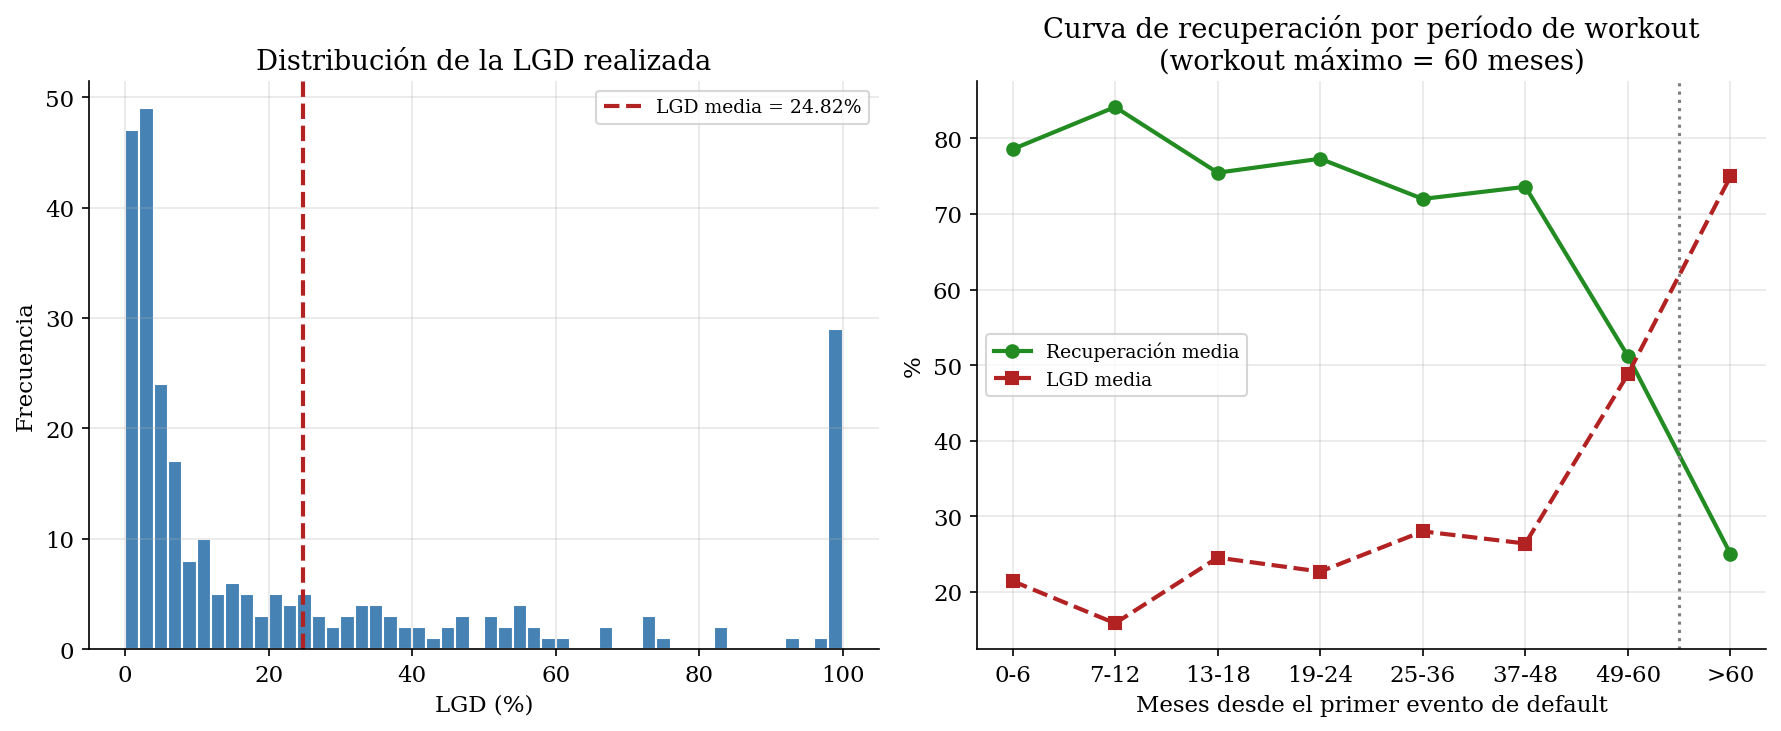

--- ead_amortizacion_prepago.png ---


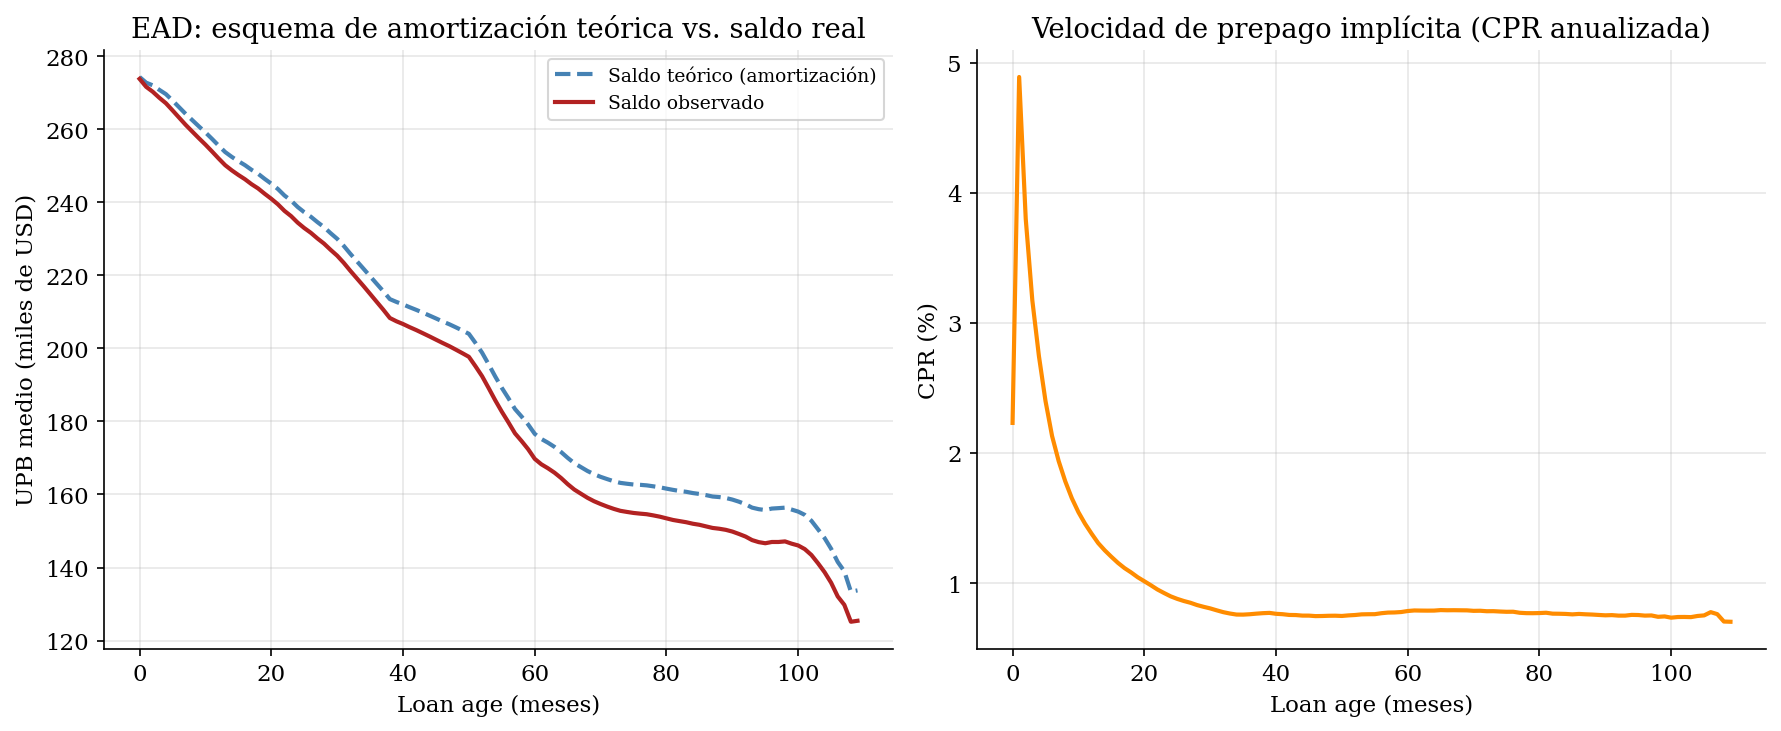

In [51]:
# -- Resultados clave de LGD y EAD ----------------------------------------------
lgd_pol = pd.read_csv(TABLAS_PATH / "lgd_politica_perdida_total.csv")
display(lgd_pol)
display(ead_resumen.T.rename(columns={0: "valor"}))

from IPython.display import Image
for img_name in ["lgd_curva_recuperacion.png", "ead_amortizacion_prepago.png"]:
    img_path = FIG_DIR / img_name
    if img_path.exists():
        print(f"--- {img_name} ---")
        display(Image(filename=str(img_path), width=850))

del ead_resumen


## 14. Paso 9 - Costo de la Regulacion: Scorecard WoE vs. ML sin restricciones

Compara dos arquitecturas de modelado bajo el mismo marco IFRS 9 y la misma particion out-of-time (train 2016-2020 | val 2022-2023 | test 2024):

- **Familia A - Scorecard regulatorio (WoE):** Regresion Logistica, XGBoost y Random Forest entrenados sobre variables transformadas a Weight of Evidence (bins ajustados en train, con Information Value por variable). Es el enfoque clasico de scorecard de credito (Siddiqi, 2006), interpretable por diseno pero con estructura impuesta.
- **Familia B - ML sin restricciones (Raw):** los modelos XGBoost y Random Forest ya optimizados en el Paso 4 (variables continuas + relativas a cohorte, restricciones de monotonia sobre los drivers de riesgo pero sin discretizacion previa), calibrados isotonicamente.

Para cada modelo se recalcula el criterio de SICR (Seccion 13.5: k, delta, backstop de config.py) usando su **propia** PD de originacion y PD corriente, de modo que las diferencias en migracion a Stage 2 y en provision de ECL sean atribuibles exclusivamente a la arquitectura de modelado, no a un criterio de staging externo comun.

> **Dependencia:** requiere los Pasos 3, 3b y 4 ya ejecutados (dataset de modelado y modelo_pd_originacion.joblib disponibles).

In [52]:
import importlib.util as _iu
spec = _iu.spec_from_file_location("m09", SRC_DIR / "09_woe_vs_ml.py")
m = _iu.module_from_spec(spec)
sys.modules[spec.name] = m  # necesario para que joblib pueda picklear
                            # clases definidas en este modulo (p.ej.
                            # ModeloCalibraado, _ModeloOrigCal); sin esto
                            # joblib.dump() falla con PicklingError.
spec.loader.exec_module(m)
df_metricas_cmp, df_sicr_cmp, df_ecl_cmp = m.main()


PASO 9 – Costo de la Regulación (WoE) vs. Machine Learning (Raw)


Dataset cargado: 14,481,471 filas | 26 features

  [Familia A – Scorecard WoE] Ajustando bins y entrenando LR/XGB/RF...


                    variable     IV               fuerza
                credit_score 0.5318 sospechoso (revisar)
             fico_vs_cohorte 0.4667               fuerte
            amortizacion_upb 0.2906                medio
estimated_loan_to_value_eltv 0.2421                medio
                original_dti 0.2353                medio
             rate_vs_cohorte 0.1783                medio
                   age_ratio 0.1315                medio
               original_cltv 0.1303                medio
                original_ltv 0.1234                medio
                    loan_age 0.1096                medio
              ltv_vs_cohorte 0.0951                débil
         number_of_borrowers 0.0808                débil
          original_loan_term 0.0706                débil
                loan_purpose 0.0393                débil
              upb_vs_cohorte 0.0263                débil

  [Familia A] Entrenando modelo de PD en originación (WoE)...


  Modelos WoE guardados en outputs/modelos/.

  [Familia B – ML sin restricciones (Raw)] Cargando modelos ya calibrados...



  LGD downturn aplicada al ECL comparativo: 24.83% (ponderada 19.83% + add-on 5%)


...

  [XGB_WoE             ] AUC=0.7818 Gini=0.5637 KS=0.4594 Brier=0.0030 O/E=2.452


  [RF_WoE              ] AUC=0.7826 Gini=0.5653 KS=0.4462 Brier=0.0031 O/E=2.650


  [XGB_Raw_Calibrado   ] AUC=0.8540 Gini=0.7080 KS=0.5450 Brier=0.0028 O/E=2.347


  [RF_Raw_Calibrado    ] AUC=0.8560 Gini=0.7121 KS=0.5571 Brier=0.0028 O/E=2.267

  === Comparación de discriminación y calibración (test 2024) ===
           modelo    AUC   Gini     KS  Brier  PD_media_predicha  tasa_default_observada  ratio_O_E
           LR_WoE 0.7917 0.5834 0.4512 0.0030             0.0078                  0.0030     2.6050
          XGB_WoE 0.7818 0.5637 0.4594 0.0030             0.0074                  0.0030     2.4520
           RF_WoE 0.7826 0.5653 0.4462 0.0031             0.0080                  0.0030     2.6500
XGB_Raw_Calibrado 0.8540 0.7080 0.5450 0.0028             0.0071                  0.0030     2.3470
 RF_Raw_Calibrado 0.8560 0.7121 0.5571 0.0028             0.0068                  0.0030     2.2670

  === Migración a Stage 2 (SICR) y falsos positivos por modelo ===
           modelo  pct_stage2  tasa_default_stage2  tasa_default_stage1  sicr_falsos_positivos      ecl_total_usd        ead_total_usd  ecl_sobre_ead_bps
           LR_WoE      0.0837 

  Figuras guardadas: woe_vs_raw_roc.png, woe_vs_raw_ecl_provisiones.png

Paso 9 completado.



In [53]:
# -- Information Value por variable (fuerza del scorecard WoE) -----------------
woe_iv = pd.read_csv(TABLAS_PATH / "woe_bins_iv.csv")
display(woe_iv)


,variable,IV,fuerza
0,credit_score,0.5318,sospechoso (revisar)
1,fico_vs_cohorte,0.4667,fuerte
2,amortizacion_upb,0.2906,medio
3,estimated_loan_to_value_eltv,0.2421,medio
4,original_dti,0.2353,medio
5,rate_vs_cohorte,0.1783,medio
6,age_ratio,0.1315,medio
7,original_cltv,0.1303,medio
8,original_ltv,0.1234,medio
9,loan_age,0.1096,medio


,modelo,AUC,Gini,KS,Brier,PD_media_predicha,tasa_default_observada,ratio_O_E
0,LR_WoE,0.7917,0.5834,0.4512,0.0030,0.7831%,0.3007%,2.605
1,XGB_WoE,0.7818,0.5637,0.4594,0.0030,0.7372%,0.3007%,2.452
2,RF_WoE,0.7826,0.5653,0.4462,0.0031,0.7967%,0.3007%,2.650
3,XGB_Raw_Calibrado,0.8540,0.7080,0.5450,0.0028,0.7057%,0.3007%,2.347
4,RF_Raw_Calibrado,0.8560,0.7121,0.5571,0.0028,0.6816%,0.3007%,2.267


,modelo,pct_stage2,tasa_default_stage2,tasa_default_stage1,sicr_falsos_positivos,ecl_total_usd,ead_total_usd,ecl_sobre_ead_bps
0,LR_WoE,8.37%,1.5823%,0.1835%,98.42%,"$1,092,313,383","$135,161,937,920",80.8
1,XGB_WoE,15.75%,0.9045%,0.1878%,99.10%,"$1,973,569,368","$135,161,937,920",146.0
2,RF_WoE,19.63%,0.8307%,0.1712%,99.17%,"$2,209,293,229","$135,161,937,920",163.5
3,XGB_Raw_Calibrado,12.21%,1.1107%,0.1880%,98.89%,"$1,258,681,076","$135,161,937,920",93.1
4,RF_Raw_Calibrado,9.46%,1.3980%,0.1860%,98.60%,"$1,192,426,889","$135,161,937,920",88.2


,modelo,pct_stage2,ecl_total_usd,ead_total_usd,ecl_sobre_ead_bps,ecl_relativo_vs_min
0,LR_WoE,8.37%,"$1,092,313,383","$135,161,937,920",80.8,1.00x
1,XGB_WoE,15.75%,"$1,973,569,368","$135,161,937,920",146.0,1.81x
2,RF_WoE,19.63%,"$2,209,293,229","$135,161,937,920",163.5,2.02x
3,XGB_Raw_Calibrado,12.21%,"$1,258,681,076","$135,161,937,920",93.1,1.15x
4,RF_Raw_Calibrado,9.46%,"$1,192,426,889","$135,161,937,920",88.2,1.09x


--- woe_vs_raw_roc.png ---


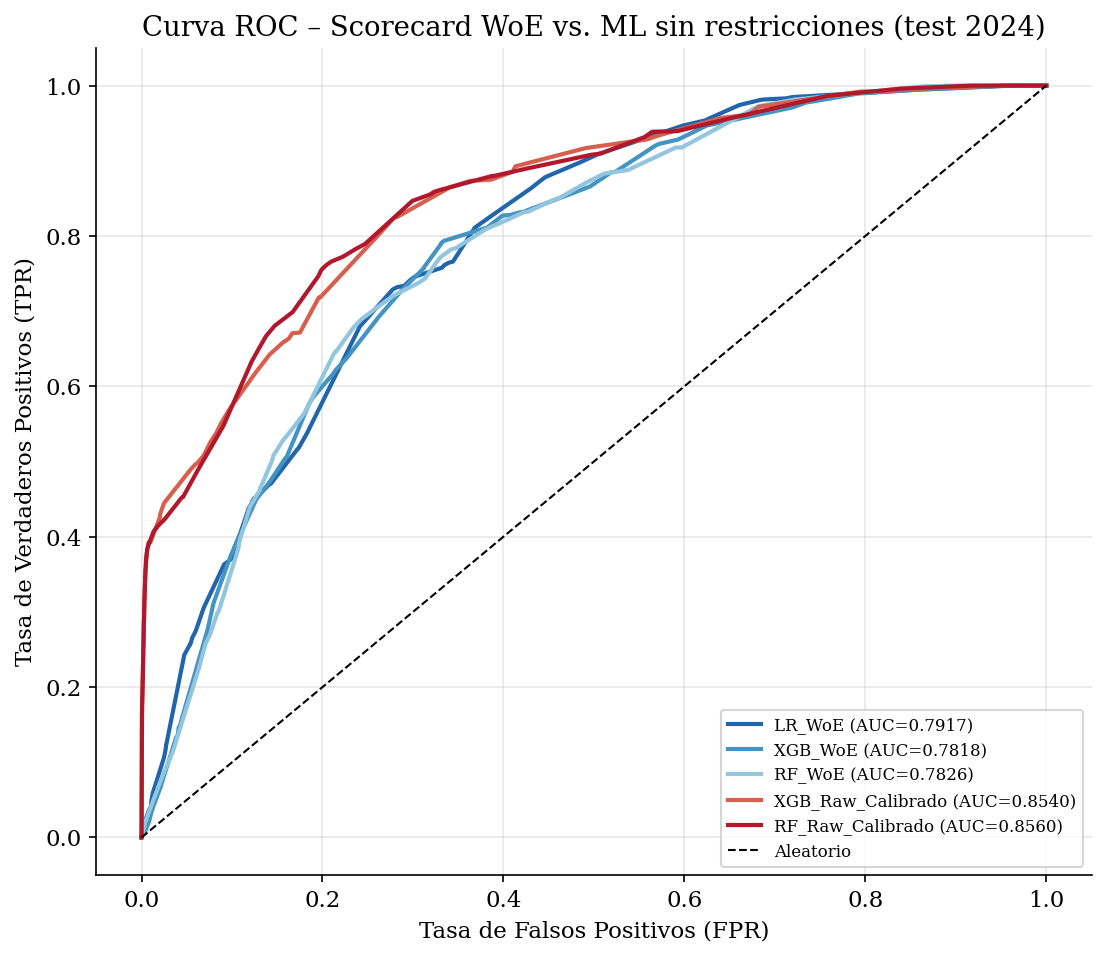

--- woe_vs_raw_ecl_provisiones.png ---


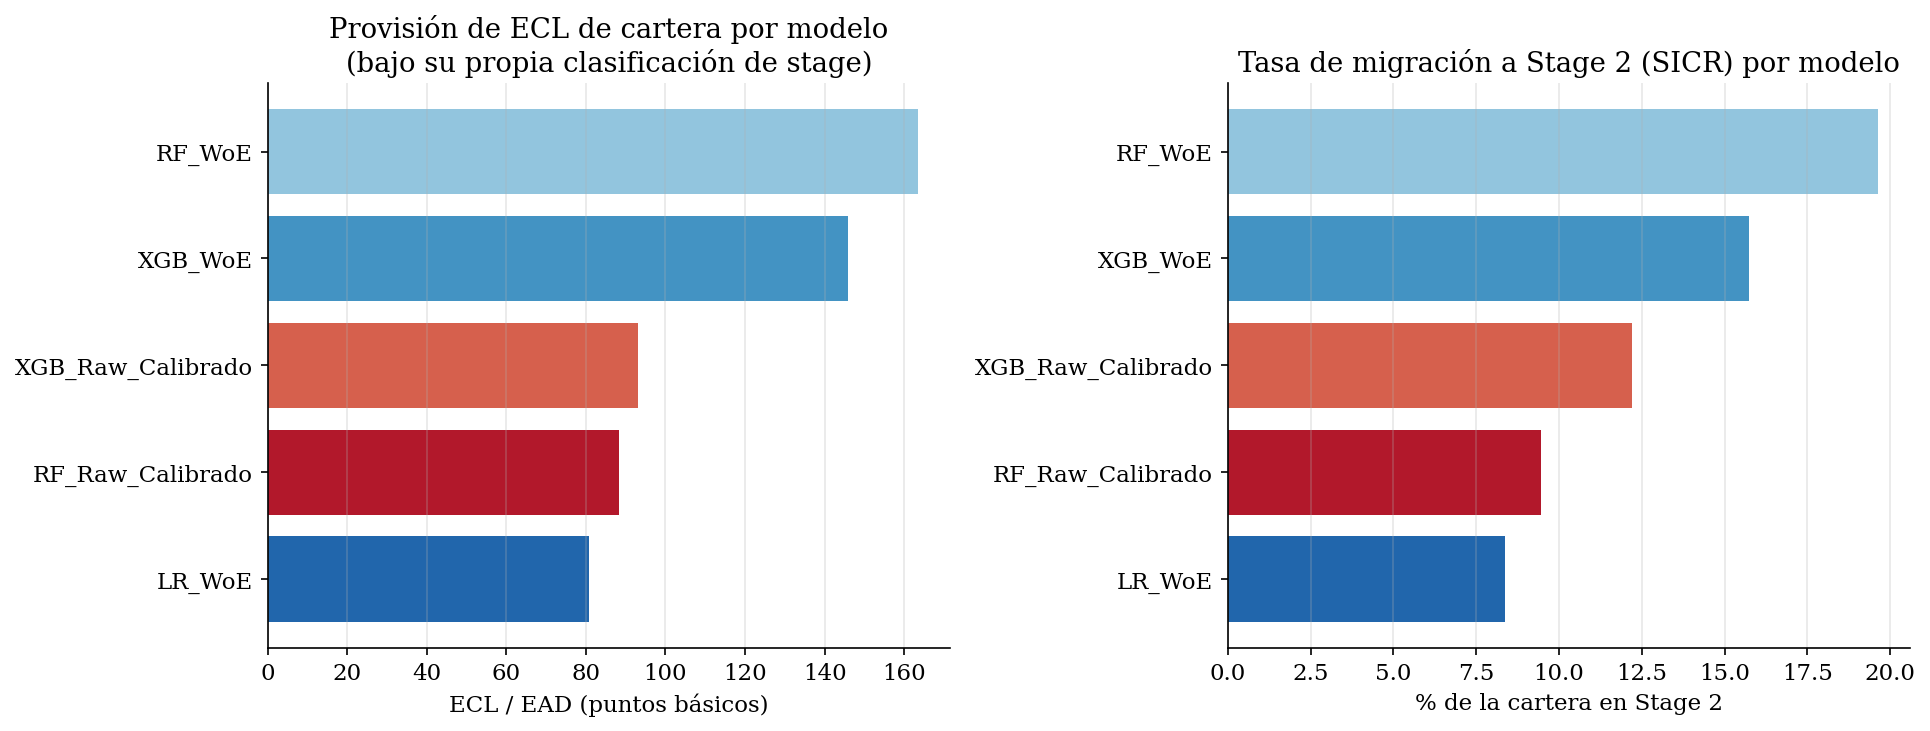

In [54]:
# -- Comparacion de discriminacion y calibracion --------------------------------
display(df_metricas_cmp.style.format(
    {"AUC": "{:.4f}", "Gini": "{:.4f}", "KS": "{:.4f}", "Brier": "{:.4f}",
     "PD_media_predicha": "{:.4%}", "tasa_default_observada": "{:.4%}",
     "ratio_O_E": "{:.3f}"}))

# -- Migracion a Stage 2 (SICR) y falsos positivos por modelo -------------------
display(df_sicr_cmp.style.format(
    {"pct_stage2": "{:.2%}", "tasa_default_stage2": "{:.4%}",
     "tasa_default_stage1": "{:.4%}", "sicr_falsos_positivos": "{:.2%}",
     "ecl_total_usd": "${:,.0f}", "ead_total_usd": "${:,.0f}",
     "ecl_sobre_ead_bps": "{:.1f}"}))

# -- Provision de ECL de cartera bajo la propia clasificacion de cada modelo ----
display(df_ecl_cmp.style.format(
    {"pct_stage2": "{:.2%}", "ecl_total_usd": "${:,.0f}", "ead_total_usd": "${:,.0f}",
     "ecl_sobre_ead_bps": "{:.1f}", "ecl_relativo_vs_min": "{:.2f}x"}))

from IPython.display import Image
for img_name in ["woe_vs_raw_roc.png", "woe_vs_raw_ecl_provisiones.png"]:
    img_path = FIG_DIR / img_name
    if img_path.exists():
        print(f"--- {img_name} ---")
        display(Image(filename=str(img_path), width=850))


**Lectura de resultados (out-of-time, vintage 2024):** la familia ML sin restricciones domina en discriminacion pura sobre la familia WoE (AUC 0.85-0.86 vs. 0.78-0.79; brecha de Gini de aproximadamente 13-15 puntos), consistente con la perdida de informacion que produce la discretizacion en bins. Sin embargo, los scorecards WoE (especialmente XGB/RF sobre variables WoE) migran una proporcion mayor de la cartera a Stage 2 con una tasa de default observada *menor* dentro de ese Stage 2 -- es decir, generan mas falsos positivos de SICR -- lo que se traduce en una provision de ECL agregada sensiblemente mas alta que la de los modelos ML calibrados para el mismo riesgo real subyacente. Este es el costo de la regulacion cuantificado: mayor interpretabilidad y gobernabilidad del scorecard WoE, a cambio de sobre-provision y menor precision en la identificacion del riesgo incremental.

## 11. Ejecutar el pipeline completo (alternativa rápida)

> Corre las secciones 1–10 en una sola celda usando `pipeline_completo.py`.
> Útil para re-ejecución completa desde cero.


In [55]:
# ⚠️  Esta celda re-ejecuta TODO el pipeline de cero. Descomentarla para usar.

# import importlib.util as _iu
# spec = _iu.spec_from_file_location("pipeline", SRC_DIR / "pipeline_completo.py")
# m = _iu.module_from_spec(spec); spec.loader.exec_module(m)
# m.main()
